# Simulación de tesorería

## Objetivo del notebook

El objetivo de este notebook es construir una serie histórica diaria de tesorería combinando información real de cobros de clientes con salidas de caja generadas sintéticamente.

El dataset público utilizado en el proyecto contiene información real sobre:

- facturas emitidas;
- clientes;
- fechas de emisión;
- fechas de vencimiento;
- importes;
- fechas reales de liquidación.

Sin embargo, no contiene información sobre:

- proveedores;
- facturas recibidas;
- nóminas;
- alquileres;
- suministros;
- impuestos;
- financiación;
- saldo bancario.

Para poder estudiar la evolución de la liquidez se generarán estos componentes mediante reglas empresariales reproducibles.

## Separación entre datos reales y sintéticos

Se mantendrá una distinción explícita entre ambos tipos de información.

### Datos reales

Los cobros de clientes se obtendrán directamente de:

- `SettledDate`;
- `InvoiceAmount`.

Por tanto:

`fecha del cobro = SettledDate`

`importe del cobro = InvoiceAmount`

### Datos sintéticos

Se generarán:

- proveedores;
- facturas de proveedores;
- pagos a proveedores;
- nóminas;
- costes sociales;
- alquiler;
- suministros;
- software y administración;
- financiación;
- impuestos simulados;
- saldo inicial de caja.

Todos los registros generados incluirán una variable que permita identificar su procedencia.

## Alcance

La serie resultante será una **simulación de tesorería**, no una reconstrucción real de la posición bancaria de la empresa.

El objetivo es demostrar cómo podrían integrarse:

- cuentas a cobrar;
- compromisos de pago;
- gastos recurrentes;
- información predictiva de cobros;

en un sistema de planificación financiera.

## Resultado esperado

El notebook generará principalmente:

`cash_movements.parquet`

Una fila representará un movimiento de caja.

Y:

`gold_daily_cashflow.parquet`

Una fila representará un día de tesorería.

Estos datasets servirán como base para la fase posterior de análisis y escenarios de liquidez.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

SYNTHETIC_DIR = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
)

for directory in [
    SYNTHETIC_DIR,
    PROCESSED_DIR,
    GOLD_DIR,
    METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

RAW_FILE = (
    RAW_DIR
    / "accounts_receivable_ibm.csv"
)

print(
    RAW_FILE.resolve()
)

C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\raw\accounts_receivable_ibm.csv


## 1. Reconstrucción de los cobros reales

La simulación de tesorería utilizará como entradas de caja los pagos efectivamente observados en el dataset original.

Para esta fase no se utilizará `gold_invoice_risk.parquet`, ya que la capa Gold del modelo de retraso fue diseñada específicamente para evitar información futura y no contiene las fechas reales de liquidación necesarias para reconstruir los cobros históricos.

Se volverá por tanto al dataset original únicamente para recuperar:

- identificador de factura;
- cliente;
- fecha de emisión;
- fecha de vencimiento;
- fecha de liquidación;
- importe.

La información se normalizará nuevamente mediante un proceso reproducible.

In [3]:
raw_df = pd.read_csv(
    RAW_FILE
)

print(
    f"Filas: {raw_df.shape[0]:,}"
)

print(
    f"Columnas: {raw_df.shape[1]}"
)

display(
    raw_df.head()
)

Filas: 2,466
Columnas: 12


,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,4/6/2013,611365,1/2/2013,2/1/2013,55.94,No,1/15/2013,Paper,13,0
1,406,8976-AMJEO,3/3/2012,7900770,1/26/2013,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6
2,391,2820-XGXSB,1/26/2012,9231909,7/3/2013,8/2/2013,65.88,No,7/8/2013,Electronic,5,0
3,406,9322-YCTQO,4/6/2012,9888306,2/10/2013,3/12/2013,105.92,No,3/17/2013,Electronic,35,5
4,818,6627-ELFBK,11/26/2012,15752855,10/25/2012,11/24/2012,72.27,Yes,11/28/2012,Paper,34,4


### Normalizar columnas

In [4]:
rename_columns = {
    "countryCode": "country_code",
    "customerID": "customer_id",
    "PaperlessDate": "paperless_date",
    "invoiceNumber": "invoice_id",
    "InvoiceDate": "invoice_date",
    "DueDate": "due_date",
    "InvoiceAmount": "invoice_amount",
    "Disputed": "disputed",
    "PaperlessBill": "paperless_bill",
    "SettledDate": "settled_date",
    "DaysToSettle": "days_to_settle_original",
    "DaysLate": "days_late_original",
}

invoices = (
    raw_df
    .rename(
        columns=rename_columns
    )
    .copy()
)

### Convertir tipos

In [5]:
date_columns = [
    "invoice_date",
    "due_date",
    "settled_date",
    "paperless_date",
]

for col in date_columns:
    invoices[col] = pd.to_datetime(
        invoices[col],
        format="%m/%d/%Y",
        errors="coerce"
    )
    
    invoices["invoice_id"] = (
    invoices["invoice_id"]
    .astype("string")
    .str.strip()
)

invoices["customer_id"] = (
    invoices["customer_id"]
    .astype("string")
    .str.strip()
)

invoices["invoice_amount"] = (
    pd.to_numeric(
        invoices["invoice_amount"],
        errors="coerce"
    )
)

### Checks

In [6]:
invoice_checks = pd.Series({
    "rows": len(invoices),

    "duplicated_invoice_id": (
        invoices["invoice_id"]
        .duplicated()
        .sum()
    ),

    "missing_invoice_date": (
        invoices["invoice_date"]
        .isna()
        .sum()
    ),

    "missing_settled_date": (
        invoices["settled_date"]
        .isna()
        .sum()
    ),

    "missing_amount": (
        invoices["invoice_amount"]
        .isna()
        .sum()
    ),

    "non_positive_amount": (
        invoices["invoice_amount"]
        <= 0
    ).sum(),

    "settled_before_invoice": (
        invoices["settled_date"]
        < invoices["invoice_date"]
    ).sum(),
})

display(invoice_checks)

assert invoices["invoice_id"].is_unique

assert invoices[
    "invoice_date"
].notna().all()

assert invoices[
    "settled_date"
].notna().all()

assert invoices[
    "invoice_amount"
].notna().all()

assert (
    invoices["invoice_amount"] > 0
).all()

print(
    "✓ Facturas preparadas correctamente."
)

rows                      2466
duplicated_invoice_id        0
missing_invoice_date         0
missing_settled_date         0
missing_amount               0
non_positive_amount          0
settled_before_invoice       0
dtype: int64

✓ Facturas preparadas correctamente.


### Construir cobros reales

In [7]:
customer_receipts = pd.DataFrame({
    "movement_id": [
        f"COL_{i:06d}"
        for i in range(
            1,
            len(invoices) + 1
        )
    ],

    "date": (
        invoices[
            "settled_date"
        ].values
    ),

    "amount": (
        invoices[
            "invoice_amount"
        ].values
    ),

    "direction": "CASH_IN",

    "movement_type": (
        "CUSTOMER_RECEIPT"
    ),

    "reference_id": (
        invoices[
            "invoice_id"
        ]
        .astype(str)
        .values
    ),

    "counterparty_id": (
        invoices[
            "customer_id"
        ]
        .astype(str)
        .values
    ),

    "data_origin": "REAL",

    "is_synthetic": False,
})

customer_receipts[
    "date"
] = pd.to_datetime(
    customer_receipts["date"]
).dt.normalize()

customer_receipts.head()

,movement_id,date,amount,direction,movement_type,reference_id,counterparty_id,data_origin,is_synthetic
0,COL_000001,2013-01-15,55.94,CASH_IN,CUSTOMER_RECEIPT,611365,0379-NEVHP,REAL,False
1,COL_000002,2013-03-03,61.74,CASH_IN,CUSTOMER_RECEIPT,7900770,8976-AMJEO,REAL,False
2,COL_000003,2013-07-08,65.88,CASH_IN,CUSTOMER_RECEIPT,9231909,2820-XGXSB,REAL,False
3,COL_000004,2013-03-17,105.92,CASH_IN,CUSTOMER_RECEIPT,9888306,9322-YCTQO,REAL,False
4,COL_000005,2012-11-28,72.27,CASH_IN,CUSTOMER_RECEIPT,15752855,6627-ELFBK,REAL,False


### Validar cobros

In [8]:
receipt_checks = pd.Series({
    "rows": len(customer_receipts),

    "missing_date": (
        customer_receipts[
            "date"
        ]
        .isna()
        .sum()
    ),

    "missing_amount": (
        customer_receipts[
            "amount"
        ]
        .isna()
        .sum()
    ),

    "non_positive_amount": (
        customer_receipts[
            "amount"
        ] <= 0
    ).sum(),

    "total_receipts": (
        customer_receipts[
            "amount"
        ].sum()
    ),
})

display(receipt_checks)

assert np.isclose(
    customer_receipts[
        "amount"
    ].sum(),

    invoices[
        "invoice_amount"
    ].sum()
)

print(
    "✓ Todos los importes facturados "
    "han sido incorporados como cobros reales."
)

rows                     2466.00
missing_date                0.00
missing_amount              0.00
non_positive_amount         0.00
total_receipts         147703.18
dtype: float64

✓ Todos los importes facturados han sido incorporados como cobros reales.


### Supuesto sobre los cobros

El dataset proporciona una única fecha de liquidación (`SettledDate`) para cada factura y no contiene información detallada sobre pagos parciales.

Por este motivo, la simulación asume que el importe completo de cada factura entra en caja en su fecha de liquidación.

Esta simplificación refleja la granularidad disponible en la fuente original y deberá revisarse si en una aplicación real se dispone de información sobre cobros parciales o múltiples movimientos asociados a una misma factura.

### Agregacion mensual de ventas

In [9]:
monthly_sales = (
    invoices
    .set_index(
        "invoice_date"
    )["invoice_amount"]
    .resample("MS")
    .sum()
)

display(monthly_sales)

monthly_sales.describe()

invoice_date
2012-01-01    5658.82
2012-02-01    5929.06
2012-03-01    6730.54
2012-04-01    6005.03
2012-05-01    6841.39
2012-06-01    5575.30
2012-07-01    6575.38
2012-08-01    6105.54
2012-09-01    6989.89
2012-10-01    6623.76
2012-11-01    6535.49
2012-12-01    6493.87
2013-01-01    6714.93
2013-02-01    6128.10
2013-03-01    6438.62
2013-04-01    6484.60
2013-05-01    7764.68
2013-06-01    5849.59
2013-07-01    6142.00
2013-08-01    6579.03
2013-09-01    6828.75
2013-10-01    5908.40
2013-11-01    6364.37
2013-12-01     436.04
Freq: MS, Name: invoice_amount, dtype: float64

count      24.000000
mean     6154.299167
std      1309.603785
min       436.040000
25%      5986.037500
50%      6461.610000
75%      6646.552500
max      7764.680000
Name: invoice_amount, dtype: float64

### Visualizar actividad mensual

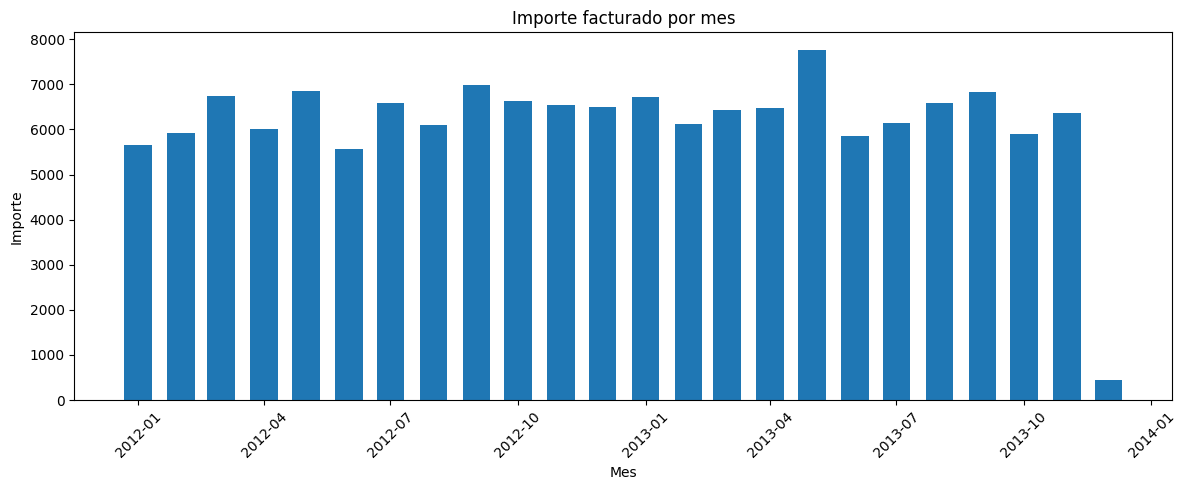

In [10]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.bar(
    monthly_sales.index,
    monthly_sales.values,
    width=20
)

ax.set_title(
    "Importe facturado por mes"
)

ax.set_xlabel(
    "Mes"
)

ax.set_ylabel(
    "Importe"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Meses frontera e histórico incompleto

El primer y el último mes del dataset pueden contener únicamente una parte del período mensual debido a las fechas de inicio y fin de la fuente.

Este problema es especialmente visible en diciembre de 2013, donde el importe facturado es muy inferior al resto de meses porque el histórico finaliza durante los primeros días del mes.

Estos meses se conservarán en los datos reales, ya que representan correctamente la información disponible en la fuente, pero no se utilizarán para estimar la escala habitual de actividad de la empresa.

Para calcular parámetros de referencia como:

- ventas mensuales medias;
- ventas mensuales medianas;
- dimensionamiento de gastos fijos;
- nivel habitual de actividad;

se utilizarán únicamente los meses interiores completos del histórico.

De esta forma se evita que períodos truncados generen gastos sintéticos artificialmente bajos.

### Detectar meses frontera

In [11]:
first_invoice_date = (
    invoices[
        "invoice_date"
    ].min()
)

last_invoice_date = (
    invoices[
        "invoice_date"
    ].max()
)

first_month = (
    first_invoice_date
    .to_period("M")
    .to_timestamp()
)

last_month = (
    last_invoice_date
    .to_period("M")
    .to_timestamp()
)

print(
    "Primera factura:",
    first_invoice_date.date()
)

print(
    "Última factura:",
    last_invoice_date.date()
)

print(
    "Primer mes frontera:",
    first_month.date()
)

print(
    "Último mes frontera:",
    last_month.date()
)

Primera factura: 2012-01-03
Última factura: 2013-12-02
Primer mes frontera: 2012-01-01
Último mes frontera: 2013-12-01


### Meses completos de referencia

In [12]:
monthly_sales_reference = (
    monthly_sales[
        (monthly_sales.index > first_month)
        &
        (monthly_sales.index < last_month)
    ]
    .copy()
)

display(
    monthly_sales_reference
)

monthly_sales_reference.describe()

invoice_date
2012-02-01    5929.06
2012-03-01    6730.54
2012-04-01    6005.03
2012-05-01    6841.39
2012-06-01    5575.30
2012-07-01    6575.38
2012-08-01    6105.54
2012-09-01    6989.89
2012-10-01    6623.76
2012-11-01    6535.49
2012-12-01    6493.87
2013-01-01    6714.93
2013-02-01    6128.10
2013-03-01    6438.62
2013-04-01    6484.60
2013-05-01    7764.68
2013-06-01    5849.59
2013-07-01    6142.00
2013-08-01    6579.03
2013-09-01    6828.75
2013-10-01    5908.40
2013-11-01    6364.37
Freq: MS, Name: invoice_amount, dtype: float64

count      22.000000
mean     6436.741818
std       475.465459
min      5575.300000
25%      6111.180000
50%      6489.235000
75%      6692.137500
max      7764.680000
Name: invoice_amount, dtype: float64

## 2. Principios de la generación sintética

Los datos sintéticos no se generarán mediante valores completamente arbitrarios.

Se utilizarán reglas reproducibles relacionadas con el nivel de actividad observado en las facturas reales.

Los principales principios serán:

### Reproducibilidad

Toda la simulación utilizará una semilla aleatoria fija.

De esta forma, ejecutar nuevamente el notebook con los mismos parámetros producirá exactamente el mismo escenario.

### Coherencia con la escala de la empresa

Los gastos se dimensionarán en relación con el volumen de facturación observado.

Por ejemplo:

- compras a proveedores como porcentaje de las ventas;
- nóminas como porcentaje de la actividad;
- suministros y gastos administrativos en proporción al tamaño empresarial.

### Diferenciación entre gastos variables y fijos

Se generarán:

**Gastos variables**

Relacionados parcialmente con el volumen de actividad:

- compras a proveedores;
- logística;
- suministros.

**Gastos relativamente fijos**

- alquiler;
- software;
- administración;
- financiación.

### Patrones temporales

Los pagos no se distribuirán completamente al azar.

Se introducirán patrones como:

- nóminas a final de mes;
- alquiler al inicio del mes;
- pagos a proveedores según vencimiento;
- cuotas financieras mensuales;
- impuestos en determinados períodos.

### Trazabilidad

Todos los datos generados tendrán:

`data_origin = SYNTHETIC`

y parámetros documentados en un fichero de configuración.

El objetivo no es recrear una empresa real concreta, sino construir un escenario empresarial coherente que permita demostrar la metodología de previsión y análisis de tesorería.

### Configuracion de la simulacion

In [13]:
SIMULATION_CONFIG = {
    "simulation_version": "1.0",

    "monetary_unit": (
        "dataset_native_monetary_units"
    ),

    "random_seed": 42,

    # -------------------------
    # Proveedores
    # -------------------------
    "supplier_count": 25,

    "supplier_cost_ratio_min": 0.38,
    "supplier_cost_ratio_max": 0.48,

    "supplier_invoices_per_month_min": 8,
    "supplier_invoices_per_month_max": 16,

    # -------------------------
    # Gastos operativos
    # -------------------------
    "payroll_ratio": 0.16,

    "social_cost_ratio": 0.05,

    "utilities_ratio": 0.015,

    # -------------------------
    # Gastos relativamente fijos
    # -------------------------
    "rent_ratio_median_sales": 0.04,

    "software_admin_ratio_median_sales": 0.012,

    "loan_payment_ratio_median_sales": 0.02,

    # -------------------------
    # Impuestos simulados
    # -------------------------
    "quarterly_tax_ratio": 0.035,

    # -------------------------
    # Liquidez inicial
    # -------------------------
    "initial_cash_months": 1.50,
}

SIMULATION_CONFIG

{'simulation_version': '1.0',
 'monetary_unit': 'dataset_native_monetary_units',
 'random_seed': 42,
 'supplier_count': 25,
 'supplier_cost_ratio_min': 0.38,
 'supplier_cost_ratio_max': 0.48,
 'supplier_invoices_per_month_min': 8,
 'supplier_invoices_per_month_max': 16,
 'payroll_ratio': 0.16,
 'social_cost_ratio': 0.05,
 'utilities_ratio': 0.015,
 'rent_ratio_median_sales': 0.04,
 'software_admin_ratio_median_sales': 0.012,
 'loan_payment_ratio_median_sales': 0.02,
 'quarterly_tax_ratio': 0.035,
 'initial_cash_months': 1.5}

### Iniciar genarador aleatorio

In [14]:
rng = np.random.default_rng(
    SIMULATION_CONFIG[
        "random_seed"
    ]
)

print(
    "✓ Generador aleatorio inicializado."
)

✓ Generador aleatorio inicializado.


### Parametros derivados de la empresa

In [15]:
median_monthly_sales = (
    monthly_sales_reference.median()
)

average_monthly_sales = (
    monthly_sales_reference.mean()
)

total_invoiced = (
    invoices[
        "invoice_amount"
    ].sum()
)

company_scale = pd.Series({
    "total_invoiced": (
        total_invoiced
    ),

    "reference_average_monthly_sales": (
        average_monthly_sales
    ),

    "reference_median_monthly_sales": (
        median_monthly_sales
    ),

    "reference_months": (
        len(monthly_sales_reference)
    ),

    "all_observed_months": (
        len(monthly_sales)
    ),
})

company_scale

total_invoiced                     147703.180000
reference_average_monthly_sales      6436.741818
reference_median_monthly_sales       6489.235000
reference_months                       22.000000
all_observed_months                    24.000000
dtype: float64

### Horizonte temporal de la simulacion

In [16]:
temporal_coverage = pd.Series({
    "first_invoice_date": (
        invoices[
            "invoice_date"
        ].min()
    ),

    "last_invoice_date": (
        invoices[
            "invoice_date"
        ].max()
    ),

    "first_receipt_date": (
        customer_receipts[
            "date"
        ].min()
    ),

    "last_receipt_date": (
        customer_receipts[
            "date"
        ].max()
    ),

    "invoice_period_days": (
        invoices[
            "invoice_date"
        ].max()
        -
        invoices[
            "invoice_date"
        ].min()
    ).days,

    "cash_receipt_period_days": (
        customer_receipts[
            "date"
        ].max()
        -
        customer_receipts[
            "date"
        ].min()
    ).days,
})

temporal_coverage

first_invoice_date          2012-01-03 00:00:00
last_invoice_date           2013-12-02 00:00:00
first_receipt_date          2012-01-13 00:00:00
last_receipt_date           2014-01-09 00:00:00
invoice_period_days                         699
cash_receipt_period_days                    727
dtype: object

### Horizonte principal de la simulación

La fuente contiene información parcial en los extremos del período temporal.

Aunque existen cobros hasta enero de 2014, las facturas emitidas solo cubren los primeros días de diciembre de 2013.

Del mismo modo, enero de 2012 comienza con el mes ya iniciado.

Para evitar combinar gastos sintéticos correspondientes a meses completos con actividad real observada únicamente durante una fracción del mes, la simulación principal utilizará únicamente meses de actividad completos.

El horizonte principal será:

- inicio: 1 de febrero de 2012;
- fin: 30 de noviembre de 2013.

Los movimientos reales situados fuera de esta ventana se conservarán en la fuente original, pero no se utilizarán para construir la serie principal de tesorería.

Esta decisión permite que los cobros reales y los gastos sintéticos se comparen dentro de períodos mensuales homogéneos.

Dentro de esta ventana quedan incluidos 2.366 de los 2.466 cobros reales disponibles, aproximadamente el 95,9 % de las observaciones y del importe total cobrado.

Los 100 cobros restantes corresponden a los períodos frontera excluidos y se mantienen únicamente para trazabilidad.

In [17]:
simulation_start_date = (
    monthly_sales_reference
    .index
    .min()
)

simulation_end_date = (
    monthly_sales_reference
    .index
    .max()
    + pd.offsets.MonthEnd(0)
)

simulation_dates = pd.date_range(
    start=simulation_start_date,
    end=simulation_end_date,
    freq="D"
)

simulation_period = pd.Series({
    "simulation_start_date": simulation_start_date,
    "simulation_end_date": simulation_end_date,
    "simulation_days": len(simulation_dates),
    "simulation_months": len(monthly_sales_reference),
})

simulation_period

simulation_start_date    2012-02-01 00:00:00
simulation_end_date      2013-11-30 00:00:00
simulation_days                          669
simulation_months                         22
dtype: object

### Filtrar los cobros de la simulacion

In [18]:
simulation_customer_receipts = (
    customer_receipts[
        customer_receipts[
            "date"
        ]
        .between(
            simulation_start_date,
            simulation_end_date
        )
    ]
    .copy()
)

print(
    "Cobros reales totales:",
    len(customer_receipts)
)

print(
    "Cobros dentro de la simulación:",
    len(simulation_customer_receipts)
)

print(
    "Importe total real:",
    customer_receipts[
        "amount"
    ].sum()
)

print(
    "Importe dentro de simulación:",
    simulation_customer_receipts[
        "amount"
    ].sum()
)

Cobros reales totales: 2466
Cobros dentro de la simulación: 2366
Importe total real: 147703.18
Importe dentro de simulación: 141713.03


### Sanity checks orientativo de costes

In [19]:
expected_cost_ratio_min = (
    SIMULATION_CONFIG[
        "supplier_cost_ratio_min"
    ]
    + SIMULATION_CONFIG[
        "payroll_ratio"
    ]
    + SIMULATION_CONFIG[
        "social_cost_ratio"
    ]
    + SIMULATION_CONFIG[
        "utilities_ratio"
    ]
    + SIMULATION_CONFIG[
        "rent_ratio_median_sales"
    ]
    + SIMULATION_CONFIG[
        "software_admin_ratio_median_sales"
    ]
    + SIMULATION_CONFIG[
        "loan_payment_ratio_median_sales"
    ]
    + SIMULATION_CONFIG[
        "quarterly_tax_ratio"
    ]
)

expected_cost_ratio_max = (
    expected_cost_ratio_min
    - SIMULATION_CONFIG[
        "supplier_cost_ratio_min"
    ]
    + SIMULATION_CONFIG[
        "supplier_cost_ratio_max"
    ]
)

print(
    "Carga orientativa mínima:",
    f"{expected_cost_ratio_min:.1%}"
)

print(
    "Carga orientativa máxima:",
    f"{expected_cost_ratio_max:.1%}"
)

print(
    "Margen orientativo restante:",
    f"{1 - expected_cost_ratio_max:.1%}",
    "a",
    f"{1 - expected_cost_ratio_min:.1%}"
)

Carga orientativa mínima: 71.2%
Carga orientativa máxima: 81.2%
Margen orientativo restante: 18.8% a 28.8%


### Coherencia orientativa de la estructura de costes

La suma de los principales ratios de gasto produce una carga orientativa situada aproximadamente entre el 71 % y el 81 % del nivel de actividad mensual.

Esto dejaría un margen aproximado del 19 % al 29 % antes de otros posibles gastos o eventos extraordinarios.

Este cálculo no representa un margen contable real.

Los distintos componentes de gasto no utilizan necesariamente el mismo denominador y algunos pagos presentan periodicidades diferentes.

Su finalidad es únicamente comprobar que los parámetros sintéticos se encuentran en una escala razonable y que la simulación no parte de una empresa estructuralmente insolvente ni de una situación artificialmente rentable.

### construir Metadata final

In [20]:
simulation_metadata = {
    **SIMULATION_CONFIG,

    "reference_average_monthly_sales": (
        float(average_monthly_sales)
    ),

    "reference_median_monthly_sales": (
        float(median_monthly_sales)
    ),

    "reference_months": (
        int(len(monthly_sales_reference))
    ),

    "all_observed_months": (
        int(len(monthly_sales))
    ),

    "simulation_start_date": (
        simulation_start_date.strftime(
            "%Y-%m-%d"
        )
    ),

    "simulation_end_date": (
        simulation_end_date.strftime(
            "%Y-%m-%d"
        )
    ),

    "source_invoice_count": (
        int(len(invoices))
    ),

    "source_receipt_count": (
        int(len(customer_receipts))
    ),

    "simulation_receipt_count": (
        int(len(simulation_customer_receipts))
    ),

    "source_receipt_amount": (
        float(
            customer_receipts[
                "amount"
            ].sum()
        )
    ),

    "simulation_receipt_amount": (
        float(
            simulation_customer_receipts[
                "amount"
            ].sum()
        )
    ),
}

### Guardar metadata

In [21]:
CONFIG_FILE = (
    METADATA_DIR
    / "cashflow_simulation_config.json"
)

with open(
    CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        simulation_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "✓ Configuración y metadatos "
    "de simulación guardados en:"
)

print(
    CONFIG_FILE.resolve()
)

✓ Configuración y metadatos de simulación guardados en:
C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\metadata\cashflow_simulation_config.json


### Verificar JSON

In [22]:
with open(
    CONFIG_FILE,
    "r",
    encoding="utf-8"
) as file:

    saved_metadata = json.load(
        file
    )

saved_metadata

{'simulation_version': '1.0',
 'monetary_unit': 'dataset_native_monetary_units',
 'random_seed': 42,
 'supplier_count': 25,
 'supplier_cost_ratio_min': 0.38,
 'supplier_cost_ratio_max': 0.48,
 'supplier_invoices_per_month_min': 8,
 'supplier_invoices_per_month_max': 16,
 'payroll_ratio': 0.16,
 'social_cost_ratio': 0.05,
 'utilities_ratio': 0.015,
 'rent_ratio_median_sales': 0.04,
 'software_admin_ratio_median_sales': 0.012,
 'loan_payment_ratio_median_sales': 0.02,
 'quarterly_tax_ratio': 0.035,
 'initial_cash_months': 1.5,
 'reference_average_monthly_sales': 6436.7418181818175,
 'reference_median_monthly_sales': 6489.235000000001,
 'reference_months': 22,
 'all_observed_months': 24,
 'simulation_start_date': '2012-02-01',
 'simulation_end_date': '2013-11-30',
 'source_invoice_count': 2466,
 'source_receipt_count': 2466,
 'simulation_receipt_count': 2366,
 'source_receipt_amount': 147703.18,
 'simulation_receipt_amount': 141713.03}

## Conclusiones de la preparación de la simulación

La primera fase del notebook ha permitido reconstruir correctamente las entradas de caja reales y establecer los parámetros básicos de la futura simulación.

## Cobros reales

Se han identificado 2.466 facturas y se ha construido un movimiento de cobro para cada una de ellas.

Las validaciones muestran:

- 0 facturas duplicadas;
- 0 fechas de emisión ausentes;
- 0 fechas de liquidación ausentes;
- 0 importes ausentes;
- 0 importes negativos o iguales a cero;
- 0 liquidaciones anteriores a la fecha de emisión.

El importe total facturado es:

`147.703,18 unidades monetarias`

y coincide exactamente con el importe total incorporado como cobros reales.

Por tanto, la conciliación entre facturas y entradas de caja reales es completa.

## Granularidad de los cobros

La fuente dispone de una única fecha de liquidación para cada factura y no proporciona información sobre pagos parciales.

La simulación asume por tanto que el importe completo de cada factura entra en caja en `SettledDate`.

## Actividad empresarial

El volumen mensual observado se sitúa habitualmente alrededor de 6.000–7.000 unidades monetarias.

El último mes del histórico de facturación está incompleto y presenta un volumen anormalmente bajo debido al corte temporal de la fuente.

Por este motivo, los meses frontera se conservan dentro de los datos reales, pero se excluyen del cálculo de los parámetros utilizados para representar el nivel habitual de actividad empresarial.

Las referencias de escala se calculan utilizando 22 meses interiores completos.

La actividad mensual de referencia presenta aproximadamente:

- media mensual ≈ 6.437 unidades monetarias;
- mediana mensual ≈ 6.489 unidades monetarias.

## Horizonte de simulación

Aunque la fuente contiene movimientos fuera de los meses completos de facturación, la simulación principal se limita al período comprendido entre febrero de 2012 y noviembre de 2013.

Esta ventana contiene 22 meses completos de actividad y evita que los períodos frontera generen distorsiones al combinar ingresos reales parciales con gastos sintéticos correspondientes a meses completos.

Los movimientos originales situados fuera de esta ventana se mantienen disponibles para trazabilidad, pero no forman parte de la serie principal de tesorería.

## Configuración sintética

Se ha definido una configuración centralizada y reproducible para generar posteriormente:

- proveedores;
- compras;
- gastos operativos;
- gastos fijos;
- financiación;
- impuestos;
- saldo inicial.

La simulación utiliza una semilla aleatoria fija:

`random_seed = 42`

para garantizar reproducibilidad.

Los parámetros se han dimensionado en relación con el volumen real de actividad y se utilizan como hipótesis de simulación, no como información observada de una empresa real.

## Coherencia orientativa de costes

La configuración implica una carga orientativa situada aproximadamente entre el 71 % y el 81 % del nivel mensual de actividad.

Este cálculo se utiliza únicamente como control de coherencia.

No representa un margen contable real.

El objetivo es evitar construir una simulación que parta de una empresa estructuralmente insolvente o, en el extremo contrario, artificialmente rentable.

## Separación real / sintético

A partir de este punto se mantendrá una distinción explícita:

### REAL

- facturas de clientes;
- fechas reales de liquidación;
- importes reales de cobro.

### SYNTHETIC

- proveedores;
- facturas de proveedores;
- gastos;
- financiación;
- impuestos;
- saldo inicial.

Esta separación deberá mantenerse durante toda la construcción de la tesorería y en la interpretación posterior de los resultados.

## Veredicto

La preparación de la simulación se considera válida.

Las entradas de caja reales están conciliadas, la escala de actividad ha sido definida utilizando meses completos y el horizonte temporal de la simulación está fijado.

El siguiente paso será generar las salidas de caja sintéticas comenzando por proveedores y facturas de proveedores.

## 3. Generación de proveedores sintéticos

El dataset original no contiene información sobre proveedores ni cuentas a pagar.

Para representar las principales salidas operativas de una empresa se generará una cartera sintética de proveedores.

Cada proveedor tendrá:

- identificador único;
- categoría de gasto;
- plazo habitual de pago;
- indicador de procedencia sintética.

Las categorías representarán distintos tipos de gasto empresarial:

- mercancías;
- servicios profesionales;
- logística;
- tecnología;
- marketing;
- mantenimiento.

Los plazos de pago posibles serán:

- 15 días;
- 30 días;
- 60 días.

La mayor parte de los proveedores utilizará un plazo de 30 días.

La generación utilizará el mismo generador aleatorio inicializado con `random_seed = 42`, por lo que el resultado será reproducible.

### Funciones auxiliares para fechas laborables

In [23]:
def move_to_next_business_day(date):
    """
    Si la fecha cae en sábado o domingo,
    la mueve al siguiente lunes.
    """

    date = pd.Timestamp(
        date
    ).normalize()

    while date.weekday() >= 5:
        date += pd.Timedelta(
            days=1
        )

    return date

def move_to_previous_business_day(date):
    """
    Si la fecha cae en sábado o domingo,
    la mueve al viernes anterior.
    """

    date = pd.Timestamp(
        date
    ).normalize()

    while date.weekday() >= 5:
        date -= pd.Timedelta(
            days=1
        )

    return date

assert (
    move_to_next_business_day(
        "2012-03-03"
    ).weekday()
    < 5
)

assert (
    move_to_previous_business_day(
        "2012-03-04"
    ).weekday()
    < 5
)

print(
    "✓ Funciones de días laborables correctas."
)

✓ Funciones de días laborables correctas.


### Generar proveedores

In [24]:
supplier_categories = [
    "MERCHANDISE",
    "PROFESSIONAL_SERVICES",
    "LOGISTICS",
    "TECHNOLOGY",
    "MARKETING",
    "MAINTENANCE",
]

supplier_category_probabilities = [
    0.35,
    0.20,
    0.15,
    0.12,
    0.10,
    0.08,
]

supplier_count = (
    SIMULATION_CONFIG[
        "supplier_count"
    ]
)

suppliers = pd.DataFrame({
    "supplier_id": [
        f"SUP_{i:03d}"
        for i in range(
            1,
            supplier_count + 1
        )
    ],

    "supplier_category": (
        rng.choice(
            supplier_categories,
            size=supplier_count,
            replace=True,
            p=supplier_category_probabilities,
        )
    ),

    "usual_payment_terms": (
        rng.choice(
            [15, 30, 60],
            size=supplier_count,
            replace=True,
            p=[
                0.15,
                0.65,
                0.20,
            ],
        )
    ),

    "data_origin": "SYNTHETIC",

    "is_synthetic": True,
})

suppliers.head()

,supplier_id,supplier_category,usual_payment_terms,data_origin,is_synthetic
0,SUP_001,TECHNOLOGY,30,SYNTHETIC,True
1,SUP_002,PROFESSIONAL_SERVICES,30,SYNTHETIC,True
2,SUP_003,MARKETING,15,SYNTHETIC,True
3,SUP_004,LOGISTICS,30,SYNTHETIC,True
4,SUP_005,MERCHANDISE,30,SYNTHETIC,True


### Validar proveedores

In [25]:
supplier_checks = pd.Series({
    "rows": len(suppliers),

    "duplicated_supplier_id": (
        suppliers[
            "supplier_id"
        ]
        .duplicated()
        .sum()
    ),

    "missing_category": (
        suppliers[
            "supplier_category"
        ]
        .isna()
        .sum()
    ),

    "missing_payment_terms": (
        suppliers[
            "usual_payment_terms"
        ]
        .isna()
        .sum()
    ),

    "unique_categories": (
        suppliers[
            "supplier_category"
        ]
        .nunique()
    ),
})

display(supplier_checks)

assert (
    len(suppliers)
    ==
    SIMULATION_CONFIG[
        "supplier_count"
    ]
)

assert suppliers[
    "supplier_id"
].is_unique

assert suppliers[
    "supplier_category"
].notna().all()

assert suppliers[
    "usual_payment_terms"
].isin(
    [15, 30, 60]
).all()

print(
    "✓ Proveedores sintéticos validados."
)

rows                      25
duplicated_supplier_id     0
missing_category           0
missing_payment_terms      0
unique_categories          6
dtype: int64

✓ Proveedores sintéticos validados.


### Distribucion de proveedores

In [26]:
supplier_category_summary = (
    suppliers[
        "supplier_category"
    ]
    .value_counts()
    .rename_axis(
        "supplier_category"
    )
    .to_frame(
        "supplier_count"
    )
)

display(supplier_category_summary)

supplier_payment_terms_summary = (
    suppliers[
        "usual_payment_terms"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "payment_terms_days"
    )
    .to_frame(
        "supplier_count"
    )
)

supplier_payment_terms_summary

,supplier_count
supplier_category,
TECHNOLOGY,5
PROFESSIONAL_SERVICES,5
MARKETING,4
LOGISTICS,4
MERCHANDISE,4
MAINTENANCE,3


,supplier_count
payment_terms_days,
15,3
30,18
60,4


## 4. Generación de facturas de proveedores

Las compras mensuales a proveedores se dimensionarán utilizando el volumen real de facturación observado en cada mes completo.

Para cada mes se seleccionará aleatoriamente un ratio de coste de proveedores dentro del intervalo definido:

`38 % – 48 %`

El importe total de compras del mes será:

`ventas mensuales × supplier_cost_ratio`

Posteriormente, ese importe se distribuirá entre un número aleatorio de facturas comprendido entre:

`8 y 16 facturas mensuales`

La suma de las facturas generadas deberá coincidir con el coste de proveedores definido para ese mes.

Cada factura incluirá:

- proveedor;
- categoría;
- fecha de emisión;
- plazo de pago;
- fecha de vencimiento;
- importe;
- fecha real de pago simulada.

La fecha de pago se situará alrededor del vencimiento, permitiendo pequeños adelantos o retrasos para evitar una estructura de pagos completamente determinista.

### Preparar lookup de proveedores

In [27]:
supplier_lookup = (
    suppliers
    .set_index(
        "supplier_id"
    )
)

simulation_months = (
    monthly_sales_reference
    .index
)

print(
    "Meses a simular:",
    len(simulation_months)
)

Meses a simular: 22


### Generar facturas de proveedores

In [28]:
supplier_invoice_rows = []

supplier_invoice_counter = 1

for month_start, month_sales in (
    monthly_sales_reference.items()
):

    # -----------------------------
    # Número de facturas del mes
    # -----------------------------

    invoice_count = int(
        rng.integers(
            SIMULATION_CONFIG[
                "supplier_invoices_per_month_min"
            ],
            SIMULATION_CONFIG[
                "supplier_invoices_per_month_max"
            ] + 1,
        )
    )

    # -----------------------------
    # Ratio de compras del mes
    # -----------------------------

    supplier_cost_ratio = (
        rng.uniform(
            SIMULATION_CONFIG[
                "supplier_cost_ratio_min"
            ],
            SIMULATION_CONFIG[
                "supplier_cost_ratio_max"
            ],
        )
    )

    monthly_supplier_cost = (
        float(month_sales)
        * supplier_cost_ratio
    )

    # -----------------------------
    # Repartir coste entre facturas
    # -----------------------------

    weights = rng.dirichlet(
        np.full(
            invoice_count,
            2.0
        )
    )

    invoice_amounts = np.round(
        monthly_supplier_cost
        * weights,
        2
    )

    # Ajustamos redondeo para que
    # la suma mensual cuadre exactamente
    rounding_adjustment = round(
        monthly_supplier_cost
        - invoice_amounts.sum(),
        2
    )

    invoice_amounts[-1] += (
        rounding_adjustment
    )

    # -----------------------------
    # Crear cada factura
    # -----------------------------

    for invoice_amount in (
        invoice_amounts
    ):

        supplier_id = rng.choice(
            suppliers[
                "supplier_id"
            ].to_numpy()
        )

        supplier_data = (
            supplier_lookup
            .loc[
                supplier_id
            ]
        )

        days_in_month = (
            month_start.days_in_month
        )

        issue_day = int(
            rng.integers(
                1,
                days_in_month + 1
            )
        )

        invoice_date = (
            month_start
            + pd.Timedelta(
                days=issue_day - 1
            )
        )

        payment_terms = int(
            supplier_data[
                "usual_payment_terms"
            ]
        )

        due_date = (
            invoice_date
            + pd.Timedelta(
                days=payment_terms
            )
        )

        due_date = (
            move_to_next_business_day(
                due_date
            )
        )

        # Pequeña variación alrededor
        # del vencimiento
        payment_delay_days = int(
            np.clip(
                np.round(
                    rng.normal(
                        loc=1.5,
                        scale=3.5
                    )
                ),
                -3,
                12
            )
        )

        payment_date = (
            due_date
            + pd.Timedelta(
                days=payment_delay_days
            )
        )

        payment_date = (
            move_to_next_business_day(
                payment_date
            )
        )

        supplier_invoice_rows.append({
            "supplier_invoice_id": (
                f"PINV_"
                f"{supplier_invoice_counter:06d}"
            ),

            "supplier_id": (
                supplier_id
            ),

            "supplier_category": (
                supplier_data[
                    "supplier_category"
                ]
            ),

            "activity_month": (
                month_start
            ),

            "invoice_date": (
                invoice_date
            ),

            "payment_terms_days": (
                payment_terms
            ),

            "due_date": (
                due_date
            ),

            "payment_date": (
                payment_date
            ),

            "invoice_amount": (
                round(
                    float(
                        invoice_amount
                    ),
                    2
                )
            ),

            "data_origin": (
                "SYNTHETIC"
            ),

            "is_synthetic": True,
        })

        supplier_invoice_counter += 1


supplier_invoices = pd.DataFrame(
    supplier_invoice_rows
)

supplier_invoices.head()

,supplier_invoice_id,supplier_id,supplier_category,activity_month,invoice_date,payment_terms_days,due_date,payment_date,invoice_amount,data_origin,is_synthetic
0,PINV_000001,SUP_005,MERCHANDISE,2012-02-01,2012-02-13,30,2012-03-14,2012-03-13,213.72,SYNTHETIC,True
1,PINV_000002,SUP_021,TECHNOLOGY,2012-02-01,2012-02-10,60,2012-04-10,2012-04-10,41.79,SYNTHETIC,True
2,PINV_000003,SUP_001,TECHNOLOGY,2012-02-01,2012-02-23,30,2012-03-26,2012-03-29,116.77,SYNTHETIC,True
3,PINV_000004,SUP_019,MARKETING,2012-02-01,2012-02-21,30,2012-03-22,2012-03-26,138.05,SYNTHETIC,True
4,PINV_000005,SUP_005,MERCHANDISE,2012-02-01,2012-02-28,30,2012-03-29,2012-04-02,80.61,SYNTHETIC,True


### Validaciones de facturas de proveedores

In [29]:
supplier_invoice_checks = pd.Series({
    "rows": (
        len(
            supplier_invoices
        )
    ),

    "duplicated_invoice_id": (
        supplier_invoices[
            "supplier_invoice_id"
        ]
        .duplicated()
        .sum()
    ),

    "missing_supplier": (
        supplier_invoices[
            "supplier_id"
        ]
        .isna()
        .sum()
    ),

    "missing_amount": (
        supplier_invoices[
            "invoice_amount"
        ]
        .isna()
        .sum()
    ),

    "non_positive_amount": (
        supplier_invoices[
            "invoice_amount"
        ] <= 0
    ).sum(),

    "due_before_invoice": (
        supplier_invoices[
            "due_date"
        ]
        <
        supplier_invoices[
            "invoice_date"
        ]
    ).sum(),

    "payment_before_invoice": (
        supplier_invoices[
            "payment_date"
        ]
        <
        supplier_invoices[
            "invoice_date"
        ]
    ).sum(),
})

display(supplier_invoice_checks)

assert supplier_invoices[
    "supplier_invoice_id"
].is_unique

assert (
    supplier_invoices[
        "invoice_amount"
    ] > 0
).all()

assert not (
    supplier_invoices[
        "due_date"
    ]
    <
    supplier_invoices[
        "invoice_date"
    ]
).any()

assert not (
    supplier_invoices[
        "payment_date"
    ]
    <
    supplier_invoices[
        "invoice_date"
    ]
).any()

print(
    "✓ Facturas de proveedores validadas."
)

rows                      273
duplicated_invoice_id       0
missing_supplier            0
missing_amount              0
non_positive_amount         0
due_before_invoice          0
payment_before_invoice      0
dtype: int64

✓ Facturas de proveedores validadas.


### Validar ratio mensual de compras

In [30]:
supplier_monthly_summary = (
    supplier_invoices
    .groupby(
        "activity_month"
    )
    .agg(
        supplier_invoice_count=(
            "supplier_invoice_id",
            "count"
        ),

        supplier_cost=(
            "invoice_amount",
            "sum"
        ),
    )
)

supplier_monthly_summary[
    "monthly_sales"
] = (
    monthly_sales_reference
)

supplier_monthly_summary[
    "supplier_cost_ratio"
] = (
    supplier_monthly_summary[
        "supplier_cost"
    ]
    /
    supplier_monthly_summary[
        "monthly_sales"
    ]
)

supplier_monthly_summary

,supplier_invoice_count,supplier_cost,monthly_sales,supplier_cost_ratio
activity_month,,,,
2012-02-01,15,2257.41,5929.06,0.380737
2012-03-01,12,2763.53,6730.54,0.410596
2012-04-01,16,2304.38,6005.03,0.383742
2012-05-01,9,3260.77,6841.39,0.476624
2012-06-01,9,2148.38,5575.30,0.385339
2012-07-01,10,2812.87,6575.38,0.427788
2012-08-01,9,2669.60,6105.54,0.437242
2012-09-01,9,3101.47,6989.89,0.443708
2012-10-01,9,2979.45,6623.76,0.449812


### Comprobar rango 38-48 %

In [31]:
supplier_ratio_checks = pd.Series({
    "min_supplier_ratio": (
        supplier_monthly_summary[
            "supplier_cost_ratio"
        ].min()
    ),

    "max_supplier_ratio": (
        supplier_monthly_summary[
            "supplier_cost_ratio"
        ].max()
    ),

    "average_supplier_ratio": (
        supplier_monthly_summary[
            "supplier_cost_ratio"
        ].mean()
    ),

    "total_supplier_cost": (
        supplier_monthly_summary[
            "supplier_cost"
        ].sum()
    ),
})

display(supplier_ratio_checks)

assert (
    supplier_monthly_summary[
        "supplier_cost_ratio"
    ]
    >= (
        SIMULATION_CONFIG[
            "supplier_cost_ratio_min"
        ]
        - 0.001
    )
).all()

assert (
    supplier_monthly_summary[
        "supplier_cost_ratio"
    ]
    <= (
        SIMULATION_CONFIG[
            "supplier_cost_ratio_max"
        ]
        + 0.001
    )
).all()

print(
    "✓ Costes mensuales de proveedores "
    "dentro del rango configurado."
)

min_supplier_ratio            0.380451
max_supplier_ratio            0.476624
average_supplier_ratio        0.421818
total_supplier_cost       59875.350000
dtype: float64

✓ Costes mensuales de proveedores dentro del rango configurado.


### Visualizar ratio mensual de proveedores

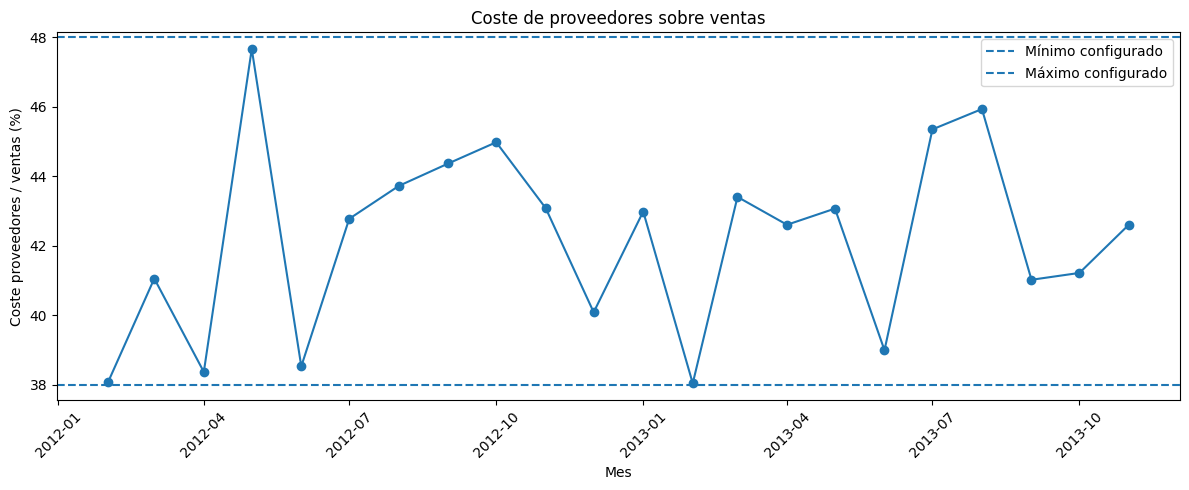

In [32]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    supplier_monthly_summary.index,
    supplier_monthly_summary[
        "supplier_cost_ratio"
    ] * 100,
    marker="o"
)

ax.axhline(
    SIMULATION_CONFIG[
        "supplier_cost_ratio_min"
    ] * 100,
    linestyle="--",
    label="Mínimo configurado"
)

ax.axhline(
    SIMULATION_CONFIG[
        "supplier_cost_ratio_max"
    ] * 100,
    linestyle="--",
    label="Máximo configurado"
)

ax.set_title(
    "Coste de proveedores sobre ventas"
)

ax.set_xlabel(
    "Mes"
)

ax.set_ylabel(
    "Coste proveedores / ventas (%)"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

## 5. Construcción de pagos a proveedores

Cada factura de proveedor genera una salida de caja en su fecha de pago simulada.

Se conservarán todas las facturas sintéticas para trazabilidad.

Sin embargo, para la serie principal de tesorería únicamente se incorporarán pagos cuya fecha se encuentre dentro del horizonte:

`01/02/2012 – 30/11/2013`

Las facturas cuyo vencimiento o pago se produce después del final de la simulación permanecerán registradas como compromisos pendientes, pero no generarán una salida de caja dentro del período analizado.

Esto permite diferenciar entre:

- gasto comprometido;
- flujo de caja efectivamente producido.

### Construir todos los pagos de proveedores

In [33]:
supplier_payments = pd.DataFrame({
    "movement_id": [
        f"SUPPAY_{i:06d}"
        for i in range(
            1,
            len(
                supplier_invoices
            ) + 1
        )
    ],

    "date": (
        supplier_invoices[
            "payment_date"
        ].values
    ),

    "amount": (
        supplier_invoices[
            "invoice_amount"
        ].values
    ),

    "direction": "CASH_OUT",

    "movement_type": (
        "SUPPLIER_PAYMENT"
    ),

    "reference_id": (
        supplier_invoices[
            "supplier_invoice_id"
        ]
        .astype(str)
        .values
    ),

    "counterparty_id": (
        supplier_invoices[
            "supplier_id"
        ]
        .astype(str)
        .values
    ),

    "data_origin": (
        "SYNTHETIC"
    ),

    "is_synthetic": True,
})

supplier_payments[
    "date"
] = pd.to_datetime(
    supplier_payments[
        "date"
    ]
).dt.normalize()

supplier_payments.head()

,movement_id,date,amount,direction,movement_type,reference_id,counterparty_id,data_origin,is_synthetic
0,SUPPAY_000001,2012-03-13,213.72,CASH_OUT,SUPPLIER_PAYMENT,PINV_000001,SUP_005,SYNTHETIC,True
1,SUPPAY_000002,2012-04-10,41.79,CASH_OUT,SUPPLIER_PAYMENT,PINV_000002,SUP_021,SYNTHETIC,True
2,SUPPAY_000003,2012-03-29,116.77,CASH_OUT,SUPPLIER_PAYMENT,PINV_000003,SUP_001,SYNTHETIC,True
3,SUPPAY_000004,2012-03-26,138.05,CASH_OUT,SUPPLIER_PAYMENT,PINV_000004,SUP_019,SYNTHETIC,True
4,SUPPAY_000005,2012-04-02,80.61,CASH_OUT,SUPPLIER_PAYMENT,PINV_000005,SUP_005,SYNTHETIC,True


### Filtrar pagos dentro del horizonte

In [34]:
simulation_supplier_payments = (
    supplier_payments[
        supplier_payments[
            "date"
        ]
        .between(
            simulation_start_date,
            simulation_end_date
        )
    ]
    .copy()
)

print(
    "Pagos proveedor totales:",
    len(
        supplier_payments
    )
)

print(
    "Pagos dentro de simulación:",
    len(
        simulation_supplier_payments
    )
)

print(
    "Importe total facturado:",
    supplier_invoices[
        "invoice_amount"
    ].sum()
)

print(
    "Importe pagado dentro del horizonte:",
    simulation_supplier_payments[
        "amount"
    ].sum()
)

Pagos proveedor totales: 273
Pagos dentro de simulación: 255
Importe total facturado: 59875.34999999999
Importe pagado dentro del horizonte: 56857.740000000005


### Compromisos pendientes al final

In [35]:
supplier_payables_at_end = (
    supplier_invoices[
        supplier_invoices[
            "payment_date"
        ]
        > simulation_end_date
    ]
    .copy()
)

ending_supplier_payables = pd.Series({
    "outstanding_invoice_count": (
        len(
            supplier_payables_at_end
        )
    ),

    "outstanding_amount": (
        supplier_payables_at_end[
            "invoice_amount"
        ].sum()
    ),
})

ending_supplier_payables

outstanding_invoice_count      18.00
outstanding_amount           3017.61
dtype: float64

### Validar conciliacion proveedor

In [36]:
supplier_reconciliation = pd.Series({
    "total_supplier_invoices": (
        supplier_invoices[
            "invoice_amount"
        ].sum()
    ),

    "paid_inside_simulation": (
        simulation_supplier_payments[
            "amount"
        ].sum()
    ),

    "payable_after_simulation": (
        supplier_payables_at_end[
            "invoice_amount"
        ].sum()
    ),
})

display(supplier_reconciliation)

assert np.isclose(
    supplier_reconciliation[
        "total_supplier_invoices"
    ],

    supplier_reconciliation[
        "paid_inside_simulation"
    ]
    +
    supplier_reconciliation[
        "payable_after_simulation"
    ],
)

print(
    "✓ Facturas de proveedores conciliadas."
)

total_supplier_invoices     59875.35
paid_inside_simulation      56857.74
payable_after_simulation     3017.61
dtype: float64

✓ Facturas de proveedores conciliadas.


## 6. Generación de gastos recurrentes

Además de los pagos a proveedores se simularán otros compromisos habituales de una empresa.

Se generarán mensualmente:

- nóminas;
- costes sociales;
- alquiler;
- suministros;
- software y administración;
- cuota de financiación.

También se generarán impuestos de forma trimestral.

## Reglas utilizadas

### Nóminas

Se calcularán como:

`ventas mensuales × payroll_ratio`

y se pagarán aproximadamente al final de cada mes.

### Costes sociales

Se calcularán como:

`ventas mensuales × social_cost_ratio`

y se pagarán a final de mes.

### Alquiler

Será relativamente fijo y se dimensionará utilizando la mediana mensual de ventas:

`median_monthly_sales × rent_ratio_median_sales`

### Software y administración

También se considerará relativamente fijo:

`median_monthly_sales × software_admin_ratio_median_sales`

### Financiación

Se simulará una cuota mensual constante:

`median_monthly_sales × loan_payment_ratio_median_sales`

### Suministros

Variarán ligeramente cada mes alrededor de:

`ventas mensuales × utilities_ratio`

### Impuestos

Se simulará un pago trimestral calculado como un porcentaje de las ventas acumuladas del trimestre.

Estas reglas son hipótesis de simulación y no representan obligaciones fiscales o laborales reales de una empresa concreta.

### Gastos fijos base

In [37]:
monthly_rent = (
    median_monthly_sales
    * SIMULATION_CONFIG[
        "rent_ratio_median_sales"
    ]
)

monthly_software_admin = (
    median_monthly_sales
    * SIMULATION_CONFIG[
        "software_admin_ratio_median_sales"
    ]
)

monthly_loan_payment = (
    median_monthly_sales
    * SIMULATION_CONFIG[
        "loan_payment_ratio_median_sales"
    ]
)

fixed_expense_reference = pd.Series({
    "monthly_rent": (
        monthly_rent
    ),

    "monthly_software_admin": (
        monthly_software_admin
    ),

    "monthly_loan_payment": (
        monthly_loan_payment
    ),
})

fixed_expense_reference

monthly_rent              259.56940
monthly_software_admin     77.87082
monthly_loan_payment      129.78470
dtype: float64

### Generar gastos mensuales

In [38]:
recurring_expense_rows = []

expense_counter = 1

for month_start, month_sales in (
    monthly_sales_reference.items()
):

    days_in_month = (
        month_start.days_in_month
    )

    month_end = (
        month_start
        + pd.offsets.MonthEnd(0)
    )

    # -----------------------------
    # Alquiler
    # -----------------------------

    rent_date = (
        move_to_next_business_day(
            month_start
        )
    )

    recurring_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            month_start
        ),

        "payment_date": (
            rent_date
        ),

        "expense_type": (
            "RENT"
        ),

        "amount": round(
            monthly_rent,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

    # -----------------------------
    # Software / administración
    # -----------------------------

    software_date = (
        move_to_next_business_day(
            month_start
            + pd.Timedelta(
                days=4
            )
        )
    )

    recurring_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            month_start
        ),

        "payment_date": (
            software_date
        ),

        "expense_type": (
            "SOFTWARE_ADMIN"
        ),

        "amount": round(
            monthly_software_admin,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

    # -----------------------------
    # Suministros
    # -----------------------------

    utilities_variation = (
        rng.uniform(
            0.85,
            1.15
        )
    )

    utilities_amount = (
        float(month_sales)
        * SIMULATION_CONFIG[
            "utilities_ratio"
        ]
        * utilities_variation
    )

    utilities_date = (
        move_to_next_business_day(
            month_start
            + pd.Timedelta(
                days=9
            )
        )
    )

    recurring_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            month_start
        ),

        "payment_date": (
            utilities_date
        ),

        "expense_type": (
            "UTILITIES"
        ),

        "amount": round(
            utilities_amount,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

    # -----------------------------
    # Financiación
    # -----------------------------

    loan_date = (
        move_to_next_business_day(
            month_start
            + pd.Timedelta(
                days=14
            )
        )
    )

    recurring_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            month_start
        ),

        "payment_date": (
            loan_date
        ),

        "expense_type": (
            "LOAN_PAYMENT"
        ),

        "amount": round(
            monthly_loan_payment,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

    # -----------------------------
    # Nóminas
    # -----------------------------

    payroll_amount = (
        float(month_sales)
        * SIMULATION_CONFIG[
            "payroll_ratio"
        ]
    )

    payroll_date = (
        move_to_previous_business_day(
            month_end
        )
    )

    recurring_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            month_start
        ),

        "payment_date": (
            payroll_date
        ),

        "expense_type": (
            "PAYROLL"
        ),

        "amount": round(
            payroll_amount,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

    # -----------------------------
    # Costes sociales
    # -----------------------------

    social_cost_amount = (
        float(month_sales)
        * SIMULATION_CONFIG[
            "social_cost_ratio"
        ]
    )

    social_cost_date = (
        move_to_previous_business_day(
            month_end
            - pd.Timedelta(
                days=2
            )
        )
    )

    recurring_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            month_start
        ),

        "payment_date": (
            social_cost_date
        ),

        "expense_type": (
            "SOCIAL_COST"
        ),

        "amount": round(
            social_cost_amount,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

recurring_expenses = pd.DataFrame(
    recurring_expense_rows
)

recurring_expenses.head()

,expense_id,activity_month,payment_date,expense_type,amount,data_origin,is_synthetic
0,EXP_000001,2012-02-01,2012-02-01,RENT,259.57,SYNTHETIC,True
1,EXP_000002,2012-02-01,2012-02-06,SOFTWARE_ADMIN,77.87,SYNTHETIC,True
2,EXP_000003,2012-02-01,2012-02-10,UTILITIES,90.29,SYNTHETIC,True
3,EXP_000004,2012-02-01,2012-02-15,LOAN_PAYMENT,129.78,SYNTHETIC,True
4,EXP_000005,2012-02-01,2012-02-29,PAYROLL,948.65,SYNTHETIC,True


### Generar impuestos trimestrales

In [39]:
monthly_sales_df = (
    monthly_sales_reference
    .rename(
        "monthly_sales"
    )
    .to_frame()
    .reset_index()
    .rename(
        columns={
            "invoice_date": (
                "month_start"
            )
        }
    )
)

monthly_sales_df.columns = [
    "month_start",
    "monthly_sales",
]

monthly_sales_df[
    "quarter"
] = (
    monthly_sales_df[
        "month_start"
    ]
    .dt.to_period(
        "Q"
    )
)

quarterly_sales = (
    monthly_sales_df
    .groupby(
        "quarter"
    )
    .agg(
        quarter_sales=(
            "monthly_sales",
            "sum"
        ),

        months_available=(
            "month_start",
            "count"
        ),
    )
    .reset_index()
)

quarterly_sales = (
    quarterly_sales[
        quarterly_sales[
            "months_available"
        ] == 3
    ]
    .copy()
)

quarterly_sales

,quarter,quarter_sales,months_available
1,2012Q2,18421.72,3
2,2012Q3,19670.81,3
3,2012Q4,19653.12,3
4,2013Q1,19281.65,3
5,2013Q2,20098.87,3
6,2013Q3,19549.78,3


### Crear pagos de impuestos

In [40]:
tax_expense_rows = []

for _, row in (
    quarterly_sales.iterrows()
):

    quarter = (
        row["quarter"]
    )

    quarter_sales_amount = (
        row["quarter_sales"]
    )

    quarter_end = (
        quarter.end_time.normalize()
    )

    payment_date = (
        quarter_end
        + pd.Timedelta(
            days=20
        )
    )

    payment_date = (
        move_to_next_business_day(
            payment_date
        )
    )

    # Solo pagos dentro del horizonte
    if not (
        simulation_start_date
        <= payment_date
        <= simulation_end_date
    ):
        continue

    tax_amount = (
        quarter_sales_amount
        * SIMULATION_CONFIG[
            "quarterly_tax_ratio"
        ]
    )

    tax_expense_rows.append({
        "expense_id": (
            f"EXP_{expense_counter:06d}"
        ),

        "activity_month": (
            quarter_end
            .to_period("M")
            .to_timestamp()
        ),

        "payment_date": (
            payment_date
        ),

        "expense_type": (
            "QUARTERLY_TAX"
        ),

        "amount": round(
            tax_amount,
            2
        ),

        "data_origin": (
            "SYNTHETIC"
        ),

        "is_synthetic": True,
    })

    expense_counter += 1

tax_expenses = pd.DataFrame(
    tax_expense_rows
)

tax_expenses

,expense_id,activity_month,payment_date,expense_type,amount,data_origin,is_synthetic
0,EXP_000133,2012-06-01,2012-07-20,QUARTERLY_TAX,644.76,SYNTHETIC,True
1,EXP_000134,2012-09-01,2012-10-22,QUARTERLY_TAX,688.48,SYNTHETIC,True
2,EXP_000135,2012-12-01,2013-01-21,QUARTERLY_TAX,687.86,SYNTHETIC,True
3,EXP_000136,2013-03-01,2013-04-22,QUARTERLY_TAX,674.86,SYNTHETIC,True
4,EXP_000137,2013-06-01,2013-07-22,QUARTERLY_TAX,703.46,SYNTHETIC,True
5,EXP_000138,2013-09-01,2013-10-21,QUARTERLY_TAX,684.24,SYNTHETIC,True


### Combinar gastos recurrentes e impuestos

In [41]:
all_recurring_expenses = pd.concat(
    [
        recurring_expenses,
        tax_expenses,
    ],
    ignore_index=True,
)

all_recurring_expenses = (
    all_recurring_expenses
    .sort_values(
        [
            "payment_date",
            "expense_id"
        ]
    )
    .reset_index(
        drop=True
    )
)

all_recurring_expenses.head()

,expense_id,activity_month,payment_date,expense_type,amount,data_origin,is_synthetic
0,EXP_000001,2012-02-01,2012-02-01,RENT,259.57,SYNTHETIC,True
1,EXP_000002,2012-02-01,2012-02-06,SOFTWARE_ADMIN,77.87,SYNTHETIC,True
2,EXP_000003,2012-02-01,2012-02-10,UTILITIES,90.29,SYNTHETIC,True
3,EXP_000004,2012-02-01,2012-02-15,LOAN_PAYMENT,129.78,SYNTHETIC,True
4,EXP_000006,2012-02-01,2012-02-27,SOCIAL_COST,296.45,SYNTHETIC,True


### Validaciones de gastos

In [42]:
expense_checks = pd.Series({
    "rows": (
        len(
            all_recurring_expenses
        )
    ),

    "duplicated_expense_id": (
        all_recurring_expenses[
            "expense_id"
        ]
        .duplicated()
        .sum()
    ),

    "missing_date": (
        all_recurring_expenses[
            "payment_date"
        ]
        .isna()
        .sum()
    ),

    "missing_amount": (
        all_recurring_expenses[
            "amount"
        ]
        .isna()
        .sum()
    ),

    "non_positive_amount": (
        all_recurring_expenses[
            "amount"
        ] <= 0
    ).sum(),

    "outside_simulation": (
        ~all_recurring_expenses[
            "payment_date"
        ].between(
            simulation_start_date,
            simulation_end_date
        )
    ).sum(),

    "total_expenses": (
        all_recurring_expenses[
            "amount"
        ].sum()
    ),
})

display(expense_checks)

assert all_recurring_expenses[
    "expense_id"
].is_unique

assert (
    all_recurring_expenses[
        "amount"
    ] > 0
).all()

assert all_recurring_expenses[
    "payment_date"
].between(
    simulation_start_date,
    simulation_end_date
).all()

print(
    "✓ Gastos recurrentes validados."
)

rows                       138.00
duplicated_expense_id        0.00
missing_date                 0.00
missing_amount               0.00
non_positive_amount          0.00
outside_simulation           0.00
total_expenses           46193.54
dtype: float64

✓ Gastos recurrentes validados.


### Resumen por tipo de gasto

In [43]:
expense_type_summary = (
    all_recurring_expenses
    .groupby(
        "expense_type"
    )
    .agg(
        movement_count=(
            "expense_id",
            "count"
        ),

        total_amount=(
            "amount",
            "sum"
        ),

        average_amount=(
            "amount",
            "mean"
        ),
    )
    .sort_values(
        "total_amount",
        ascending=False
    )
)

expense_type_summary

,movement_count,total_amount,average_amount
expense_type,,,
PAYROLL,22,22657.33,1029.878636
SOCIAL_COST,22,7080.42,321.837273
RENT,22,5710.54,259.570000
QUARTERLY_TAX,6,4083.66,680.610000
LOAN_PAYMENT,22,2855.16,129.780000
UTILITIES,22,2093.29,95.149545
SOFTWARE_ADMIN,22,1713.14,77.870000


## 7. Cuentas a pagar existentes al inicio de la simulación

La simulación comienza el 1 de febrero de 2012, pero la empresa representada no debe interpretarse como una empresa que inicia su actividad en esa fecha.

En una situación real existirían facturas de proveedores emitidas durante los meses anteriores cuyo pago todavía estaría pendiente al comenzar el período analizado.

La generación actual de proveedores comienza en febrero de 2012. Debido a los plazos de pago de 15, 30 y 60 días, esto produciría artificialmente pocas salidas por proveedores durante las primeras semanas de la simulación.

Para evitar este efecto frontera se generará un pequeño conjunto de **cuentas a pagar iniciales sintéticas**.

Estas facturas:

- tendrán fecha de emisión anterior al inicio de la simulación;
- utilizarán los mismos proveedores y condiciones de pago;
- estarán dimensionadas con el nivel habitual de actividad de la empresa;
- solo se incorporarán si su fecha de pago cae dentro del horizonte simulado;
- se identificarán explícitamente como obligaciones de apertura.

Estas obligaciones representan compromisos financieros ya existentes en la fecha inicial y no actividad generada durante el horizonte principal.

### Crear RNG independiente para apertura

In [44]:
opening_rng = np.random.default_rng(
    SIMULATION_CONFIG["random_seed"] + 1000
)

### Fenerar facturas anteriores al horizonte

In [45]:
opening_activity_months = pd.date_range(
    end=simulation_start_date - pd.offsets.MonthBegin(1),
    periods=2,
    freq="MS"
)

opening_activity_months

DatetimeIndex(['2011-12-01', '2012-01-01'], dtype='datetime64[ns]', freq='MS')

### Generar obligaciones de apertura

In [46]:
opening_supplier_invoice_rows = []

opening_invoice_counter = 1

for month_start in opening_activity_months:

    reference_sales = float(
        median_monthly_sales
    )

    invoice_count = int(
        opening_rng.integers(
            SIMULATION_CONFIG[
                "supplier_invoices_per_month_min"
            ],
            SIMULATION_CONFIG[
                "supplier_invoices_per_month_max"
            ] + 1
        )
    )

    supplier_cost_ratio = (
        opening_rng.uniform(
            SIMULATION_CONFIG[
                "supplier_cost_ratio_min"
            ],
            SIMULATION_CONFIG[
                "supplier_cost_ratio_max"
            ],
        )
    )

    monthly_supplier_cost = (
        reference_sales
        * supplier_cost_ratio
    )

    weights = opening_rng.dirichlet(
        np.full(
            invoice_count,
            2.0
        )
    )

    invoice_amounts = np.round(
        monthly_supplier_cost
        * weights,
        2
    )

    rounding_adjustment = round(
        monthly_supplier_cost
        - invoice_amounts.sum(),
        2
    )

    invoice_amounts[-1] += (
        rounding_adjustment
    )

    for invoice_amount in invoice_amounts:

        supplier_id = opening_rng.choice(
            suppliers[
                "supplier_id"
            ].to_numpy()
        )

        supplier_data = (
            supplier_lookup.loc[
                supplier_id
            ]
        )

        issue_day = int(
            opening_rng.integers(
                1,
                month_start.days_in_month + 1
            )
        )

        invoice_date = (
            month_start
            + pd.Timedelta(
                days=issue_day - 1
            )
        )

        payment_terms = int(
            supplier_data[
                "usual_payment_terms"
            ]
        )

        due_date = (
            invoice_date
            + pd.Timedelta(
                days=payment_terms
            )
        )

        due_date = (
            move_to_next_business_day(
                due_date
            )
        )

        payment_delay_days = int(
            np.clip(
                np.round(
                    opening_rng.normal(
                        loc=1.5,
                        scale=3.5
                    )
                ),
                -3,
                12
            )
        )

        payment_date = (
            due_date
            + pd.Timedelta(
                days=payment_delay_days
            )
        )

        payment_date = (
            move_to_next_business_day(
                payment_date
            )
        )

        opening_supplier_invoice_rows.append({
            "supplier_invoice_id": (
                f"OPEN_PINV_"
                f"{opening_invoice_counter:05d}"
            ),

            "supplier_id": supplier_id,

            "supplier_category": (
                supplier_data[
                    "supplier_category"
                ]
            ),

            "activity_month": month_start,

            "invoice_date": invoice_date,

            "payment_terms_days": (
                payment_terms
            ),

            "due_date": due_date,

            "payment_date": payment_date,

            "invoice_amount": round(
                float(invoice_amount),
                2
            ),

            "data_origin": "SYNTHETIC",

            "is_synthetic": True,

            "opening_liability": True,
        })

        opening_invoice_counter += 1

### Obligaciones vivas al inicio

In [47]:
opening_supplier_invoices = pd.DataFrame(
    opening_supplier_invoice_rows
)

opening_supplier_invoices = (
    opening_supplier_invoices[
        opening_supplier_invoices[
            "payment_date"
        ]
        >= simulation_start_date
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

opening_supplier_invoices.head()

,supplier_invoice_id,supplier_id,supplier_category,activity_month,invoice_date,payment_terms_days,due_date,payment_date,invoice_amount,data_origin,is_synthetic,opening_liability
0,OPEN_PINV_00007,SUP_021,TECHNOLOGY,2011-12-01,2011-12-25,60,2012-02-23,2012-02-20,84.53,SYNTHETIC,True,True
1,OPEN_PINV_00012,SUP_007,TECHNOLOGY,2011-12-01,2011-12-21,60,2012-02-20,2012-02-22,315.96,SYNTHETIC,True,True
2,OPEN_PINV_00013,SUP_017,LOGISTICS,2011-12-01,2011-12-05,60,2012-02-03,2012-02-07,212.52,SYNTHETIC,True,True
3,OPEN_PINV_00015,SUP_021,TECHNOLOGY,2012-01-01,2012-01-16,60,2012-03-16,2012-03-22,239.75,SYNTHETIC,True,True
4,OPEN_PINV_00016,SUP_018,MERCHANDISE,2012-01-01,2012-01-16,30,2012-02-15,2012-02-16,174.13,SYNTHETIC,True,True


### Crear pagos de apertura dentro del horizonte

In [48]:
opening_supplier_payments = pd.DataFrame({
    "movement_id": [
        f"OPEN_SUPPAY_{i:05d}"
        for i in range(
            1,
            len(
                opening_supplier_invoices
            ) + 1
        )
    ],

    "date": (
        opening_supplier_invoices[
            "payment_date"
        ].values
    ),

    "amount": (
        opening_supplier_invoices[
            "invoice_amount"
        ].values
    ),

    "direction": "CASH_OUT",

    "movement_type": (
        "OPENING_SUPPLIER_PAYMENT"
    ),

    "reference_id": (
        opening_supplier_invoices[
            "supplier_invoice_id"
        ].values
    ),

    "counterparty_id": (
        opening_supplier_invoices[
            "supplier_id"
        ].values
    ),

    "data_origin": "SYNTHETIC",

    "is_synthetic": True,

    "opening_liability": True,
})

opening_supplier_payments = (
    opening_supplier_payments[
        opening_supplier_payments[
            "date"
        ].between(
            simulation_start_date,
            simulation_end_date
        )
    ]
    .copy()
)

### Resumen

In [49]:
opening_payables_summary = pd.Series({
    "opening_invoice_count": (
        len(
            opening_supplier_invoices
        )
    ),

    "opening_payment_count": (
        len(
            opening_supplier_payments
        )
    ),

    "opening_payable_amount": (
        opening_supplier_invoices[
            "invoice_amount"
        ].sum()
    ),

    "opening_paid_inside_simulation": (
        opening_supplier_payments[
            "amount"
        ].sum()
    ),
})

opening_payables_summary

opening_invoice_count               18.00
opening_payment_count               18.00
opening_payable_amount            3088.19
opening_paid_inside_simulation    3088.19
dtype: float64

### Homegeneizar el indicador de obligacion de apertura

In [50]:
supplier_invoices[
    "opening_liability"
] = False

simulation_supplier_payments[
    "opening_liability"
] = False

opening_supplier_invoices[
    "opening_liability"
] = True

opening_supplier_payments[
    "opening_liability"
] = True

# Validaciones específicas de las obligaciones iniciales

assert opening_supplier_invoices[
    "supplier_invoice_id"
].is_unique

assert (
    opening_supplier_invoices[
        "invoice_date"
    ]
    < simulation_start_date
).all()

assert opening_supplier_invoices[
    "payment_date"
].between(
    simulation_start_date,
    simulation_end_date
).all()

assert opening_supplier_payments[
    "movement_id"
].is_unique

assert opening_supplier_payments[
    "date"
].between(
    simulation_start_date,
    simulation_end_date
).all()

assert np.isclose(
    opening_supplier_invoices[
        "invoice_amount"
    ].sum(),

    opening_supplier_payments[
        "amount"
    ].sum()
)

print(
    "✓ Obligaciones iniciales validadas."
)

✓ Obligaciones iniciales validadas.


### Sanity check global

In [51]:
reference_sales_total = (
    monthly_sales_reference.sum()
)

supplier_committed_cost = (
    supplier_invoices[
        "invoice_amount"
    ].sum()
)

recurring_cost = (
    all_recurring_expenses[
        "amount"
    ].sum()
)

simulation_cash_out_without_opening = (
    simulation_supplier_payments[
        "amount"
    ].sum()
    +
    recurring_cost
)

simulation_cash_out_with_opening = (
    simulation_cash_out_without_opening
    +
    opening_supplier_payments[
        "amount"
    ].sum()
)

synthetic_cost_summary = pd.Series({
    "reference_sales_total": (
        reference_sales_total
    ),

    "real_receipts_inside_simulation": (
        simulation_customer_receipts[
            "amount"
        ].sum()
    ),

    "supplier_committed_cost": (
        supplier_committed_cost
    ),

    "recurring_cost": (
        recurring_cost
    ),

    "committed_cost_total": (
        supplier_committed_cost
        + recurring_cost
    ),

    "committed_cost_ratio_vs_sales": (
        (
            supplier_committed_cost
            + recurring_cost
        )
        / reference_sales_total
    ),

    "cash_out_without_opening": (
        simulation_cash_out_without_opening
    ),

    "opening_supplier_payments": (
        opening_supplier_payments[
            "amount"
        ].sum()
    ),

    "cash_out_with_opening": (
        simulation_cash_out_with_opening
    ),

    "cash_out_ratio_vs_receipts": (
        simulation_cash_out_with_opening
        /
        simulation_customer_receipts[
            "amount"
        ].sum()
    ),
})

synthetic_cost_summary

reference_sales_total              141608.320000
real_receipts_inside_simulation    141713.030000
supplier_committed_cost             59875.350000
recurring_cost                      46193.540000
committed_cost_total               106068.890000
committed_cost_ratio_vs_sales           0.749030
cash_out_without_opening           103051.280000
opening_supplier_payments            3088.190000
cash_out_with_opening              106139.470000
cash_out_ratio_vs_receipts              0.748975
dtype: float64

## Conclusiones de la generación de salidas sintéticas

La generación de las salidas de caja sintéticas produce una estructura financiera coherente con la escala de actividad observada en los datos reales.

### Proveedores

Se han generado:

- 25 proveedores sintéticos;
- 6 categorías de proveedor;
- condiciones de pago de 15, 30 y 60 días;
- 273 facturas de proveedor.

El importe total comprometido con proveedores asciende a:

`59.875,35 unidades monetarias`

El coste mensual de proveedores se mantiene dentro del intervalo configurado del 38 % al 48 % de las ventas, con un ratio medio aproximado del:

`42,18 %`

Al final del horizonte permanecen pendientes:

- 18 facturas;
- 3.017,61 unidades monetarias.

Estas obligaciones representan cuentas a pagar existentes al cierre y, por tanto, no generan todavía una salida de caja dentro del período analizado.

### Gastos recurrentes

Se han generado 138 movimientos correspondientes a:

- nóminas;
- costes sociales;
- alquiler;
- suministros;
- software y administración;
- financiación;
- impuestos trimestrales.

Su importe total asciende a:

`46.193,54 unidades monetarias`

Todos los movimientos han superado las validaciones de fecha, importe y pertenencia al horizonte temporal.

### Obligaciones de apertura

Para evitar que la simulación comenzase artificialmente sin cuentas a pagar, se han generado obligaciones procedentes de los dos meses anteriores al inicio del horizonte.

Se incorporan:

- 18 obligaciones iniciales;
- 3.088,19 unidades monetarias de pagos dentro de la simulación.

Estas obligaciones representan compromisos existentes al comenzar el período y se mantienen identificadas mediante `opening_liability = True`.

### Coherencia global

Las ventas utilizadas como referencia ascienden a:

`141.608,32 unidades monetarias`

Los costes generados por la actividad del horizonte son:

- proveedores: 59.875,35;
- gastos recurrentes: 46.193,54;
- total comprometido: 106.068,89.

Por tanto:

`costes comprometidos / ventas ≈ 74,90 %`

Las salidas efectivamente pagadas dentro del horizonte, incluyendo las obligaciones iniciales, ascienden a:

`106.139,47 unidades monetarias`

frente a:

`141.713,03 unidades monetarias`

de cobros reales.

Por tanto:

`cash-out / cobros ≈ 74,90 %`

La similitud entre las obligaciones iniciales y las cuentas a pagar pendientes al cierre evita que el resultado global esté significativamente sesgado por los extremos temporales de la simulación.

### Interpretación

La empresa simulada presenta una estructura operativa positiva en términos agregados, pero esto no implica necesariamente ausencia de problemas de liquidez.

La tesorería depende no solo del volumen total de cobros y pagos, sino también de su distribución temporal.

Una empresa puede generar un flujo acumulado positivo y, aun así, sufrir tensiones de caja en determinados días si los pagos se concentran antes que los cobros.

El siguiente paso será precisamente reconstruir esta dinámica mediante un libro único de movimientos y una serie diaria de saldo de tesorería.

## 8. Construcción del libro único de movimientos de caja

El siguiente paso consiste en combinar todas las entradas y salidas efectivamente producidas dentro del horizonte de simulación.

El libro de movimientos integrará:

### Entradas reales

- cobros de clientes.

### Salidas sintéticas

- pagos a proveedores;
- pagos de obligaciones existentes al inicio;
- nóminas;
- costes sociales;
- alquiler;
- suministros;
- software y administración;
- financiación;
- impuestos.

Cada movimiento utilizará un esquema común que permitirá posteriormente agregar la información por día.

El saldo inicial de caja se tratará de forma independiente y no como un ingreso, ya que representa un stock financiero existente al comienzo del período.

### Convertir gastos recurrentes a movimientos de caja

In [52]:
expense_counterparty_map = {
    "RENT": "LANDLORD",
    "SOFTWARE_ADMIN": "SOFTWARE_ADMIN_PROVIDER",
    "UTILITIES": "UTILITY_PROVIDERS",
    "LOAN_PAYMENT": "LENDER",
    "PAYROLL": "EMPLOYEES",
    "SOCIAL_COST": "SOCIAL_SECURITY",
    "QUARTERLY_TAX": "TAX_AUTHORITY",
}

expense_movement_type_map = {
    "RENT": "RENT_PAYMENT",
    "SOFTWARE_ADMIN": "SOFTWARE_ADMIN_PAYMENT",
    "UTILITIES": "UTILITIES_PAYMENT",
    "LOAN_PAYMENT": "LOAN_PAYMENT",
    "PAYROLL": "PAYROLL_PAYMENT",
    "SOCIAL_COST": "SOCIAL_COST_PAYMENT",
    "QUARTERLY_TAX": "QUARTERLY_TAX_PAYMENT",
}

recurring_cash_movements = pd.DataFrame({
    "movement_id": [
        f"REXP_{i:06d}"
        for i in range(
            1,
            len(all_recurring_expenses) + 1
        )
    ],

    "date": (
        all_recurring_expenses[
            "payment_date"
        ].values
    ),

    "amount": (
        all_recurring_expenses[
            "amount"
        ].values
    ),

    "direction": "CASH_OUT",

    "movement_type": (
        all_recurring_expenses[
            "expense_type"
        ]
        .map(
            expense_movement_type_map
        )
        .values
    ),

    "reference_id": (
        all_recurring_expenses[
            "expense_id"
        ]
        .astype(str)
        .values
    ),

    "counterparty_id": (
        all_recurring_expenses[
            "expense_type"
        ]
        .map(
            expense_counterparty_map
        )
        .values
    ),

    "data_origin": "SYNTHETIC",

    "is_synthetic": True,

    "opening_liability": False,

    "source_table": (
        "RECURRING_EXPENSES"
    ),
})

### Preparar las otras 3 fuentes

In [53]:
customer_cash_movements = (
    simulation_customer_receipts
    .copy()
)

customer_cash_movements[
    "opening_liability"
] = False

customer_cash_movements[
    "source_table"
] = "CUSTOMER_RECEIPTS"

supplier_cash_movements = (
    simulation_supplier_payments
    .copy()
)

supplier_cash_movements[
    "source_table"
] = "SUPPLIER_PAYMENTS"

opening_supplier_cash_movements = (
    opening_supplier_payments
    .copy()
)

opening_supplier_cash_movements[
    "source_table"
] = "OPENING_SUPPLIER_PAYMENTS"

### Unificar columnas

In [54]:
cash_movement_columns = [
    "movement_id",
    "date",
    "amount",
    "direction",
    "movement_type",
    "reference_id",
    "counterparty_id",
    "data_origin",
    "is_synthetic",
    "opening_liability",
    "source_table",
]

cash_movements = pd.concat(
    [
        customer_cash_movements[
            cash_movement_columns
        ],

        supplier_cash_movements[
            cash_movement_columns
        ],

        opening_supplier_cash_movements[
            cash_movement_columns
        ],

        recurring_cash_movements[
            cash_movement_columns
        ],
    ],
    ignore_index=True,
)

cash_movements["date"] = (
    pd.to_datetime(
        cash_movements["date"]
    )
    .dt.normalize()
)

cash_movements = (
    cash_movements
    .sort_values(
        [
            "date",
            "movement_id"
        ]
    )
    .reset_index(
        drop=True
    )
)

cash_movements.head()

,movement_id,date,amount,direction,movement_type,reference_id,counterparty_id,data_origin,is_synthetic,opening_liability,source_table
0,COL_000817,2012-02-01,28.84,CASH_IN,CUSTOMER_RECEIPT,3314980148,6077-FDQRK,REAL,False,False,CUSTOMER_RECEIPTS
1,COL_001945,2012-02-01,74.01,CASH_IN,CUSTOMER_RECEIPT,7867318195,5148-SYKLB,REAL,False,False,CUSTOMER_RECEIPTS
2,REXP_000001,2012-02-01,259.57,CASH_OUT,RENT_PAYMENT,EXP_000001,LANDLORD,SYNTHETIC,True,False,RECURRING_EXPENSES
3,COL_001430,2012-02-02,32.78,CASH_IN,CUSTOMER_RECEIPT,5831823402,2687-XWAMA,REAL,False,False,CUSTOMER_RECEIPTS
4,COL_000545,2012-02-03,47.07,CASH_IN,CUSTOMER_RECEIPT,2195380883,6627-ELFBK,REAL,False,False,CUSTOMER_RECEIPTS


### Añadir importe con signo

In [55]:
cash_movements[
    "signed_amount"
] = np.where(
    cash_movements[
        "direction"
    ].eq(
        "CASH_IN"
    ),

    cash_movements[
        "amount"
    ],

    -cash_movements[
        "amount"
    ],
)

### Validar libro de caja

In [56]:
cash_movement_checks = pd.Series({
    "rows": (
        len(cash_movements)
    ),

    "duplicated_movement_id": (
        cash_movements[
            "movement_id"
        ]
        .duplicated()
        .sum()
    ),

    "missing_date": (
        cash_movements[
            "date"
        ]
        .isna()
        .sum()
    ),

    "missing_amount": (
        cash_movements[
            "amount"
        ]
        .isna()
        .sum()
    ),

    "non_positive_amount": (
        cash_movements[
            "amount"
        ] <= 0
    ).sum(),

    "outside_simulation": (
        ~cash_movements[
            "date"
        ].between(
            simulation_start_date,
            simulation_end_date
        )
    ).sum(),

    "cash_in": (
        cash_movements
        .loc[
            cash_movements[
                "direction"
            ] == "CASH_IN",
            "amount"
        ]
        .sum()
    ),

    "cash_out": (
        cash_movements
        .loc[
            cash_movements[
                "direction"
            ] == "CASH_OUT",
            "amount"
        ]
        .sum()
    ),

    "net_cashflow": (
        cash_movements[
            "signed_amount"
        ].sum()
    ),
})

display(cash_movement_checks)

assert cash_movements[
    "movement_id"
].is_unique

assert cash_movements[
    "date"
].between(
    simulation_start_date,
    simulation_end_date
).all()

assert (
    cash_movements[
        "amount"
    ] > 0
).all()

assert cash_movements[
    "direction"
].isin(
    [
        "CASH_IN",
        "CASH_OUT",
    ]
).all()

assert np.isclose(
    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_IN",
        "amount"
    ].sum(),

    simulation_customer_receipts[
        "amount"
    ].sum()
)

assert np.isclose(
    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_OUT",
        "amount"
    ].sum(),

    simulation_cash_out_with_opening
)

print(
    "✓ Libro único de movimientos validado."
)

rows                        2777.00
duplicated_movement_id         0.00
missing_date                   0.00
missing_amount                 0.00
non_positive_amount            0.00
outside_simulation             0.00
cash_in                   141713.03
cash_out                  106139.47
net_cashflow               35573.56
dtype: float64

✓ Libro único de movimientos validado.


### Resumen por tipo de movimiento

In [57]:
movement_type_summary = (
    cash_movements
    .groupby(
        [
            "direction",
            "movement_type"
        ]
    )
    .agg(
        movement_count=(
            "movement_id",
            "count"
        ),

        total_amount=(
            "amount",
            "sum"
        ),
    )
    .sort_values(
        [
            "direction",
            "total_amount"
        ],
        ascending=[
            True,
            False
        ]
    )
)

movement_type_summary

movement_count  total_amount
direction movement_type                                         
CASH_IN   CUSTOMER_RECEIPT                    2366     141713.03
CASH_OUT  SUPPLIER_PAYMENT                     255      56857.74
          PAYROLL_PAYMENT                       22      22657.33
          SOCIAL_COST_PAYMENT                   22       7080.42
          RENT_PAYMENT                          22       5710.54
          QUARTERLY_TAX_PAYMENT                  6       4083.66
          OPENING_SUPPLIER_PAYMENT              18       3088.19
          LOAN_PAYMENT                          22       2855.16
          UTILITIES_PAYMENT                     22       2093.29
          SOFTWARE_ADMIN_PAYMENT                22       1713.14

### Control explicito REAL vs SYNTHETIC

In [58]:
origin_summary = (
    cash_movements
    .groupby(
        [
            "direction",
            "data_origin",
            "is_synthetic",
        ]
    )
    .agg(
        movement_count=(
            "movement_id",
            "count"
        ),
        total_amount=(
            "amount",
            "sum"
        ),
    )
)

display(origin_summary)

assert (
    cash_movements.loc[
        cash_movements["direction"] == "CASH_IN",
        "data_origin"
    ]
    == "REAL"
).all()

assert (
    ~cash_movements.loc[
        cash_movements["direction"] == "CASH_IN",
        "is_synthetic"
    ]
).all()

assert (
    cash_movements.loc[
        cash_movements["direction"] == "CASH_OUT",
        "data_origin"
    ]
    == "SYNTHETIC"
).all()

assert (
    cash_movements.loc[
        cash_movements["direction"] == "CASH_OUT",
        "is_synthetic"
    ]
).all()

print(
    "✓ Separación REAL / SYNTHETIC validada."
)

,,,movement_count,total_amount
direction,data_origin,is_synthetic,,
CASH_IN,REAL,False,2366,141713.03
CASH_OUT,SYNTHETIC,True,411,106139.47


✓ Separación REAL / SYNTHETIC validada.


## 9. Definición del saldo inicial de tesorería

El dataset original no contiene información bancaria, por lo que el saldo de caja existente al comienzo de la simulación debe ser sintético.

Se utilizará el parámetro:

`initial_cash_months = 1.5`

El saldo inicial se calculará como 1,5 veces la salida media mensual de caja observada en el escenario construido.

Esta regla proporciona una reserva inicial relacionada con la escala operativa de la empresa.

El saldo inicial:

- no se considerará un ingreso;
- no se incorporará a `cash_movements`;
- se utilizará únicamente como stock inicial para calcular la evolución posterior de la caja.

Esta separación evita confundir liquidez disponible al inicio con generación de caja durante el período.

### Calcular gasto mensual y saldo inicial

In [59]:
monthly_cash_out = (
    cash_movements[
        cash_movements[
            "direction"
        ] == "CASH_OUT"
    ]
    .set_index(
        "date"
    )["amount"]
    .resample("MS")
    .sum()
    .reindex(
        monthly_sales_reference.index,
        fill_value=0
    )
)

display(monthly_cash_out)

average_monthly_cash_out = (
    monthly_cash_out.mean()
)

initial_cash_balance = (
    average_monthly_cash_out
    * SIMULATION_CONFIG[
        "initial_cash_months"
    ]
)

initial_cash_summary = pd.Series({
    "average_monthly_cash_out": (
        average_monthly_cash_out
    ),

    "initial_cash_months": (
        SIMULATION_CONFIG[
            "initial_cash_months"
        ]
    ),

    "initial_cash_balance": (
        initial_cash_balance
    ),
})

initial_cash_summary

invoice_date
2012-02-01    4878.63
2012-03-01    3870.45
2012-04-01    4677.15
2012-05-01    4142.48
2012-06-01    5426.09
2012-07-01    4249.62
2012-08-01    5146.67
2012-09-01    4373.80
2012-10-01    5525.27
2012-11-01    5032.81
2012-12-01    4668.80
2013-01-01    5507.12
2013-02-01    4419.82
2013-03-01    5378.30
2013-04-01    4645.47
2013-05-01    4370.37
2013-06-01    4983.94
2013-07-01    5292.39
2013-08-01    4262.68
2013-09-01    5385.22
2013-10-01    5694.34
2013-11-01    4208.05
Freq: MS, Name: amount, dtype: float64

average_monthly_cash_out    4824.521364
initial_cash_months            1.500000
initial_cash_balance        7236.782045
dtype: float64

## 10. Construcción de la serie diaria de tesorería

El libro de movimientos contiene únicamente los días en los que se produce alguna entrada o salida.

Para analizar correctamente la liquidez se construirá una serie continua que contenga todos los días del horizonte, incluidos aquellos sin movimientos.

Para cada fecha se calcularán:

- entradas de caja;
- salidas de caja;
- flujo neto;
- número de movimientos;
- saldo inicial del día;
- saldo final del día;
- flujo neto acumulado.

La relación fundamental será:

`saldo final = saldo inicial + entradas - salidas`

El saldo final de un día se convertirá en el saldo inicial del día siguiente.

### Agregar movimientos diariamente

In [60]:
daily_inflows = (
    cash_movements[
        cash_movements[
            "direction"
        ] == "CASH_IN"
    ]
    .groupby(
        "date"
    )["amount"]
    .sum()
)

daily_outflows = (
    cash_movements[
        cash_movements[
            "direction"
        ] == "CASH_OUT"
    ]
    .groupby(
        "date"
    )["amount"]
    .sum()
)

daily_movement_count = (
    cash_movements
    .groupby(
        "date"
    )["movement_id"]
    .count()
)

### Construir calendario diario

In [61]:
daily_cashflow = pd.DataFrame({
    "date": simulation_dates
})

daily_cashflow[
    "cash_in"
] = (
    daily_cashflow[
        "date"
    ]
    .map(
        daily_inflows
    )
    .fillna(0.0)
)

daily_cashflow[
    "cash_out"
] = (
    daily_cashflow[
        "date"
    ]
    .map(
        daily_outflows
    )
    .fillna(0.0)
)

daily_cashflow[
    "movement_count"
] = (
    daily_cashflow[
        "date"
    ]
    .map(
        daily_movement_count
    )
    .fillna(0)
    .astype(int)
)

### Calcular flujo neto y saldo

In [62]:
daily_cashflow[
    "net_cashflow"
] = (
    daily_cashflow[
        "cash_in"
    ]
    -
    daily_cashflow[
        "cash_out"
    ]
)

daily_cashflow[
    "cumulative_net_cashflow"
] = (
    daily_cashflow[
        "net_cashflow"
    ].cumsum()
)

daily_cashflow[
    "closing_cash_balance"
] = (
    initial_cash_balance
    +
    daily_cashflow[
        "cumulative_net_cashflow"
    ]
)

daily_cashflow[
    "opening_cash_balance"
] = (
    daily_cashflow[
        "closing_cash_balance"
    ]
    .shift(1)
)

daily_cashflow.loc[
    0,
    "opening_cash_balance"
] = initial_cash_balance

daily_cashflow = daily_cashflow[
    [
        "date",
        "opening_cash_balance",
        "cash_in",
        "cash_out",
        "net_cashflow",
        "closing_cash_balance",
        "cumulative_net_cashflow",
        "movement_count",
    ]
]

daily_cashflow.head()

,date,opening_cash_balance,cash_in,cash_out,net_cashflow,closing_cash_balance,cumulative_net_cashflow,movement_count
0,2012-02-01,7236.782045,102.85,259.57,-156.72,7080.062045,-156.72,3
1,2012-02-02,7080.062045,32.78,0.00,32.78,7112.842045,-123.94,1
2,2012-02-03,7112.842045,160.72,183.35,-22.63,7090.212045,-146.57,4
3,2012-02-04,7090.212045,289.84,0.00,289.84,7380.052045,143.27,4
4,2012-02-05,7380.052045,78.92,0.00,78.92,7458.972045,222.19,1


### Validaciones de tesoreria diaria

In [63]:
assert (
    len(daily_cashflow)
    ==
    len(simulation_dates)
)

assert daily_cashflow[
    "date"
].is_unique

assert daily_cashflow[
    "date"
].is_monotonic_increasing

assert np.isclose(
    daily_cashflow[
        "cash_in"
    ].sum(),

    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_IN",
        "amount"
    ].sum()
)

assert np.isclose(
    daily_cashflow[
        "cash_out"
    ].sum(),

    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_OUT",
        "amount"
    ].sum()
)

assert np.allclose(
    daily_cashflow[
        "closing_cash_balance"
    ],

    daily_cashflow[
        "opening_cash_balance"
    ]
    +
    daily_cashflow[
        "net_cashflow"
    ]
)

print(
    "✓ Serie diaria de tesorería validada."
)

✓ Serie diaria de tesorería validada.


### Diagnostico de liquidez

In [64]:
minimum_balance_idx = (
    daily_cashflow[
        "closing_cash_balance"
    ].idxmin()
)

maximum_balance_idx = (
    daily_cashflow[
        "closing_cash_balance"
    ].idxmax()
)

liquidity_summary = pd.Series({
    "initial_cash_balance": (
        initial_cash_balance
    ),

    "final_cash_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].iloc[-1]
    ),

    "minimum_cash_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].min()
    ),

    "minimum_balance_date": (
        daily_cashflow.loc[
            minimum_balance_idx,
            "date"
        ]
    ),

    "maximum_cash_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].max()
    ),

    "maximum_balance_date": (
        daily_cashflow.loc[
            maximum_balance_idx,
            "date"
        ]
    ),

    "negative_cash_days": (
        daily_cashflow[
            "closing_cash_balance"
        ]
        .lt(0)
        .sum()
    ),

    "total_cash_in": (
        daily_cashflow[
            "cash_in"
        ].sum()
    ),

    "total_cash_out": (
        daily_cashflow[
            "cash_out"
        ].sum()
    ),

    "net_cashflow": (
        daily_cashflow[
            "net_cashflow"
        ].sum()
    ),
})

liquidity_summary

initial_cash_balance            7236.782045
final_cash_balance             42810.342045
minimum_cash_balance            6865.132045
minimum_balance_date    2012-03-02 00:00:00
maximum_cash_balance           43633.722045
maximum_balance_date    2013-11-28 00:00:00
negative_cash_days                        0
total_cash_in                     141713.03
total_cash_out                    106139.47
net_cashflow                       35573.56
dtype: object

### Diagnostico del colchon inicial

In [65]:
minimum_cumulative_net_cashflow = (
    daily_cashflow[
        "cumulative_net_cashflow"
    ].min()
)

minimum_required_initial_cash = max(
    0.0,
    -minimum_cumulative_net_cashflow
)

liquidity_buffer_summary = pd.Series({
    "configured_initial_cash": (
        initial_cash_balance
    ),

    "minimum_required_initial_cash": (
        minimum_required_initial_cash
    ),

    "minimum_observed_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].min()
    ),

    "average_monthly_cash_out": (
        average_monthly_cash_out
    ),

    "minimum_balance_months_of_cash_out": (
        daily_cashflow[
            "closing_cash_balance"
        ].min()
        /
        average_monthly_cash_out
    ),

    "final_balance_months_of_cash_out": (
        daily_cashflow[
            "closing_cash_balance"
        ].iloc[-1]
        /
        average_monthly_cash_out
    ),
})

liquidity_buffer_summary

configured_initial_cash               7236.782045
minimum_required_initial_cash          371.650000
minimum_observed_balance              6865.132045
average_monthly_cash_out              4824.521364
minimum_balance_months_of_cash_out       1.422966
final_balance_months_of_cash_out         8.873490
dtype: float64

### Visualizar saldo diario

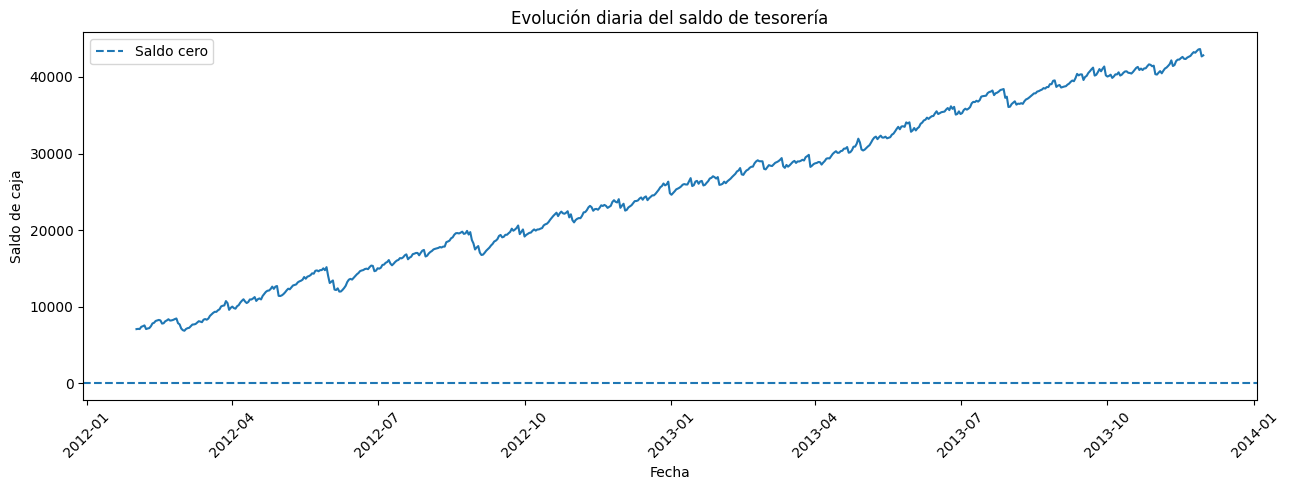

In [66]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.plot(
    daily_cashflow[
        "date"
    ],

    daily_cashflow[
        "closing_cash_balance"
    ]
)

ax.axhline(
    0,
    linestyle="--",
    label="Saldo cero"
)

ax.set_title(
    "Evolución diaria del saldo de tesorería"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Resumen mensual de tesoreria

In [67]:
monthly_cashflow = (
    daily_cashflow
    .set_index(
        "date"
    )
    .resample("MS")
    .agg(
        cash_in=(
            "cash_in",
            "sum"
        ),

        cash_out=(
            "cash_out",
            "sum"
        ),

        net_cashflow=(
            "net_cashflow",
            "sum"
        ),

        minimum_balance=(
            "closing_cash_balance",
            "min"
        ),

        closing_balance=(
            "closing_cash_balance",
            "last"
        ),
    )
)

monthly_cashflow

,cash_in,cash_out,net_cashflow,minimum_balance,closing_balance
date,,,,,
2012-02-01,4807.34,4878.63,-71.29,7080.062045,7165.492045
2012-03-01,6562.75,3870.45,2692.30,6865.132045,9857.792045
2012-04-01,6243.57,4677.15,1566.42,9751.542045,11424.212045
2012-05-01,6743.34,4142.48,2600.86,11400.122045,14025.072045
2012-06-01,6113.82,5426.09,687.73,11976.812045,14712.802045
2012-07-01,6094.49,4249.62,1844.87,14965.932045,16557.672045
2012-08-01,6064.65,5146.67,917.98,16657.752045,17475.652045
2012-09-01,6986.54,4373.80,2612.74,16755.792045,20088.392045
2012-10-01,6726.75,5525.27,1201.48,19163.222045,21289.872045


### Guardar datasets

In [68]:
# Componentes sinteticos

suppliers.to_parquet(
    SYNTHETIC_DIR
    / "suppliers.parquet",
    index=False
)

supplier_invoices.to_parquet(
    SYNTHETIC_DIR
    / "supplier_invoices.parquet",
    index=False
)

opening_supplier_invoices.to_parquet(
    SYNTHETIC_DIR
    / "opening_supplier_invoices.parquet",
    index=False
)

all_recurring_expenses.to_parquet(
    SYNTHETIC_DIR
    / "recurring_expenses.parquet",
    index=False
)

# Libro de movimientos

CASH_MOVEMENTS_FILE = (
    PROCESSED_DIR
    / "cash_movements.parquet"
)

cash_movements.to_parquet(
    CASH_MOVEMENTS_FILE,
    index=False
)

# Serie Gold

DAILY_CASHFLOW_FILE = (
    GOLD_DIR
    / "gold_daily_cashflow.parquet"
)

daily_cashflow.to_parquet(
    DAILY_CASHFLOW_FILE,
    index=False
)

### Actualizar metadata

In [69]:
simulation_metadata.update({
    "supplier_invoice_count": (
        int(len(supplier_invoices))
    ),

    "opening_supplier_invoice_count": (
        int(len(opening_supplier_invoices))
    ),

    "recurring_expense_count": (
        int(len(all_recurring_expenses))
    ),

    "cash_movement_count": (
        int(len(cash_movements))
    ),

    "total_cash_in": (
        float(
            cash_movements.loc[
                cash_movements[
                    "direction"
                ] == "CASH_IN",
                "amount"
            ].sum()
        )
    ),

    "total_cash_out": (
        float(
            cash_movements.loc[
                cash_movements[
                    "direction"
                ] == "CASH_OUT",
                "amount"
            ].sum()
        )
    ),

    "initial_cash_balance": (
        float(initial_cash_balance)
    ),

    "final_cash_balance": (
        float(
            daily_cashflow[
                "closing_cash_balance"
            ].iloc[-1]
        )
    ),

    "minimum_cash_balance": (
        float(
            daily_cashflow[
                "closing_cash_balance"
            ].min()
        )
    ),

    "negative_cash_days": (
        int(
            daily_cashflow[
                "closing_cash_balance"
            ]
            .lt(0)
            .sum()
        )
    ),
})

### Guardar metadata

In [70]:
with open(
    CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        simulation_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "✓ Metadata final actualizada."
)

✓ Metadata final actualizada.


### Verificar metadata

In [71]:
with open(
    CONFIG_FILE,
    "r",
    encoding="utf-8"
) as file:

    final_saved_metadata = json.load(
        file
    )

assert (
    final_saved_metadata[
        "cash_movement_count"
    ]
    ==
    len(cash_movements)
)

assert np.isclose(
    final_saved_metadata[
        "total_cash_in"
    ],
    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_IN",
        "amount"
    ].sum()
)

assert np.isclose(
    final_saved_metadata[
        "total_cash_out"
    ],
    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_OUT",
        "amount"
    ].sum()
)

assert np.isclose(
    final_saved_metadata[
        "final_cash_balance"
    ],
    daily_cashflow[
        "closing_cash_balance"
    ].iloc[-1]
)

assert (
    final_saved_metadata[
        "negative_cash_days"
    ]
    ==
    daily_cashflow[
        "closing_cash_balance"
    ]
    .lt(0)
    .sum()
)

print(
    "✓ Metadata final verificada correctamente."
)

✓ Metadata final verificada correctamente.


### Verificacion final de persistencia

In [72]:
reloaded_cash_movements = (
    pd.read_parquet(
        CASH_MOVEMENTS_FILE
    )
)

reloaded_daily_cashflow = (
    pd.read_parquet(
        DAILY_CASHFLOW_FILE
    )
)

assert (
    reloaded_cash_movements.shape
    ==
    cash_movements.shape
)

assert (
    reloaded_daily_cashflow.shape
    ==
    daily_cashflow.shape
)

print(
    "✓ cash_movements.parquet:",
    reloaded_cash_movements.shape
)

print(
    "✓ gold_daily_cashflow.parquet:",
    reloaded_daily_cashflow.shape
)

✓ cash_movements.parquet: (2777, 12)
✓ gold_daily_cashflow.parquet: (669, 8)


# Conclusiones finales de la simulación de tesorería

El objetivo de este notebook era construir una serie histórica diaria de tesorería combinando cobros reales de clientes con salidas de caja generadas sintéticamente.

La simulación cubre el período comprendido entre el 1 de febrero de 2012 y el 30 de noviembre de 2013, correspondiente a 669 días y 22 meses completos de actividad.

## Entradas de caja reales

Dentro del horizonte se incorporan 2.366 cobros reales procedentes del dataset original.

El importe total de entradas de caja asciende a:

`141.713,03 unidades monetarias`

Estos movimientos mantienen las fechas de liquidación y los importes observados originalmente.

Por tanto, las entradas de caja utilizadas en la simulación no han sido generadas artificialmente.

## Salidas de caja sintéticas

Las salidas se han generado mediante reglas reproducibles relacionadas con la escala real de actividad de la empresa.

Se incluyen:

- pagos a proveedores;
- obligaciones con proveedores existentes al inicio;
- nóminas;
- costes sociales;
- alquiler;
- suministros;
- software y administración;
- financiación;
- impuestos trimestrales.

El importe total pagado dentro del horizonte asciende a:

`106.139,47 unidades monetarias`

Las salidas representan aproximadamente:

`74,90 %`

de los cobros observados.

Este resultado es coherente con la estructura de costes definida previamente en la configuración de la simulación.

## Flujo neto de caja

El flujo acumulado del período es:

`+35.573,56 unidades monetarias`

por lo que el escenario base presenta generación positiva de caja.

Este resultado no representa la rentabilidad contable de una empresa real.

La simulación únicamente modela movimientos de tesorería bajo un conjunto concreto de hipótesis.

## Saldo inicial

Debido a la ausencia de información bancaria en la fuente original, el saldo inicial es necesariamente sintético.

Se ha definido como 1,5 veces la salida mensual media de caja, obteniéndose:

`7.236,78 unidades monetarias`

Este importe debe interpretarse como una hipótesis de escenario y no como una estimación de un saldo bancario real.

## Evolución de la liquidez

El saldo mínimo observado durante el período es aproximadamente:

`6.865,13 unidades monetarias`

y se produce el:

`2 de marzo de 2012`

El saldo máximo alcanza aproximadamente:

`43.633,72 unidades monetarias`

mientras que el saldo al final de la simulación es:

`42.810,34 unidades monetarias`

No se registran días con saldo negativo.

Por tanto, bajo las hipótesis del escenario base, la empresa mantiene suficiente liquidez durante todo el horizonte analizado.

## Importancia de la granularidad diaria

Aunque el resultado acumulado del período es positivo, el análisis diario permite observar fluctuaciones de liquidez que quedarían ocultas utilizando únicamente agregaciones mensuales.

El saldo mínimo ocurre durante marzo de 2012 aunque el flujo neto agregado de dicho mes es positivo.

Esto demuestra que una posición mensual favorable no garantiza que todos los días del período presenten la misma disponibilidad de caja.

La granularidad diaria es, por tanto, necesaria para identificar correctamente posibles tensiones de tesorería.

## Colchón de liquidez

Bajo los movimientos observados en este escenario, el saldo inicial estrictamente necesario para evitar valores negativos habría sido considerablemente inferior al saldo configurado.

Esto indica que el escenario base dispone de un colchón de liquidez amplio.

No se reducirá artificialmente dicho saldo para provocar episodios de déficit.

Las situaciones de estrés se estudiarán posteriormente mediante escenarios explícitos, manteniendo este escenario como referencia base.

## Separación entre datos reales y sintéticos

La simulación mantiene una separación explícita entre el origen de los movimientos.

### REAL

- cobros de clientes.

### SYNTHETIC

- proveedores;
- cuentas a pagar iniciales;
- gastos recurrentes;
- financiación;
- impuestos;
- saldo inicial.

Esta distinción es fundamental para interpretar correctamente los resultados.

La serie de tesorería no debe considerarse una reconstrucción histórica de una empresa real, sino un entorno de simulación construido sobre patrones reales de cobro.

## Datasets generados

El notebook produce dos datasets principales.

### `cash_movements.parquet`

Contiene el libro completo de movimientos de caja, con 2.777 registros.

### `gold_daily_cashflow.parquet`

Contiene la evolución diaria de tesorería durante los 669 días del horizonte.

Estos datasets constituyen la base para la siguiente fase del proyecto.

## Conclusión

La simulación construida proporciona una base coherente, reproducible y trazable para analizar la liquidez empresarial.

El escenario base presenta una posición de caja holgada y no experimenta episodios de saldo negativo.

Este resultado no invalida el objetivo del proyecto.

Al contrario, establece un escenario de referencia sobre el que podrán aplicarse posteriormente variaciones en:

- comportamiento de cobro;
- retrasos de clientes;
- nivel de gasto;
- saldo inicial;
- eventos extraordinarios.

La siguiente fase utilizará esta infraestructura para estudiar cómo el riesgo de retraso en los cobros puede trasladarse a la posición futura de tesorería.